# Dynamic LCA applied to Elmas dataset

Using electricity datasets extracted from ENTSO-E for 2018, the following calculation was performed:

France:
- Extract generation data
- Separate consumption within generation
- Extract imports data 
- Extract exports data and sum with consumption
- Calculate Generation + imports - (exports + consumption)

Neighboring countries (ES, BE, DE, CH, GB, IT):
- Extract generation data
- Separate consumption within generation
- Extract imports data
- Extract exports data
- Calculate Generation + imports

The files containing the calculations are loaded into this notebook and the imports made by France are replaced by country specific data. 

This notebook presents all the steps needed in order to obtain electricity generation data from France and its neighboring countries:

#### 1 Analysis and treatment of FR electricity data
#### 1.1 Imports from Spain Analisys
#### 1.2 Imports from Germany Analisys
#### 1.3 Imports from Belgium Analisys
#### 1.4 Imports from Great Britain Analisys
#### 1.5 Imports from Switwerland Analisys
#### 1.6 Imports from Italy Analisys
#### 1.7 Countries Imports Analysis
#### 1.8 French + Neighbors Analisys

### 2 ELMAS

ELMAS is a high-resolution industrial electricity demand dataset for France, covering 55,730 companies across 18 industrial sectors. It provides hourly electricity consumption profiles for the year 2018, enabling time-resolved analysis of energy use at the sectoral level.

#### 2.2 Static data
#### 2.1 Dynamic data
#### 2.3 Dynamic (ecoinvent match) x Static (ecoinvent - market for electricity, high voltage FR)
#### 2.4 Dynamic (ecoinvent match) x Static (ecoinvent match) 
#### 2.5 Static (ecoinvent match) x Static (ecoinvent - market for electricity, high voltage FR)

# Project creation

In [1]:
import sys
import os
import logging
import nbformat
from nbconvert.preprocessors import ExecutePreprocessor
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from brightway2 import *
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression 

# Suppress all standard output (print, logging, etc.)
class DevNull:
    def write(self, _): pass
    def flush(self): pass

sys.stdout = DevNull()
sys.stderr = DevNull()

logging.basicConfig(level=logging.CRITICAL) # Stops warnings and info about database overwritten
import lca_algebraic as agb
from lca_algebraic import *

In [2]:
bw.projects.set_current("ei_3_8")

In [3]:
USER_DB = 'user-db'
agb.resetDb(USER_DB)
agb.resetParams()
db_selected = 'ecoinvent-3.8-cutoff'

In [4]:
#In case EF is preferred, the we would have to switch to ecoinvent 3.9
EF = 'EF v3.0'

IMPACTS = [
    ('climate change', (EF, 'climate change', 'global warming potential (GWP100)')),
    ('material resources', (EF, 'material resources: metals/minerals', 'abiotic depletion potential (ADP): elements (ultimate reserves)')),
    ('land use', (EF, 'land use', 'soil quality index')),
    ('water use', (EF, 'water use', 'user deprivation potential (deprivation-weighted water consumption)')),
    ('acidification', (EF, 'acidification', 'accumulated exceedance (ae)')),
    ('marine_eutroph', (EF, 'eutrophication: marine', 'fraction of nutrients reaching marine end compartment (N)')),
    ('freshwater_eutroph', (EF, 'eutrophication: freshwater', 'fraction of nutrients reaching freshwater end compartment (P)')),
    ('terrestrial_eutroph', (EF, 'eutrophication: terrestrial', 'accumulated exceedance (AE)')),
    ('radiation', (EF, 'ionising radiation: human health', 'human exposure efficiency relative to u235')),
    ('non renewable', (EF, 'energy resources: non-renewable', 'abiotic depletion potential (ADP): fossil fuels'))
]

short_names = [imp[0] for imp in IMPACTS]
climate_change = "climate change - global warming potential (GWP100)[kg CO2-Eq]"

# 1 Analysis and treatment of FR electricity data

In [5]:
from electricity_data_loader import load_total_consumption

data_folder = r"C:\Users\jsteinbach\OneDrive - Université Paris Sciences et Lettres\PHD\entsoe_data"

df_FR_total_consumption_final, FR_2018_load = load_total_consumption(output_folder=data_folder, year=2018)


In [6]:
df_FR_total_consumption_final

,Nuclear,Hydro Run-of-river and poundage,Hydro Water Reservoir,Wind Onshore,Hydro Pumped Storage,Biomass,Fossil Gas,Fossil Hard coal,Fossil Oil,Import from DE,Import from CH,Import from UK,Import from BE,Import from IT,Import from ES
2018-01-01 00:00:00,"32,627.3","5,117.45","1,969.06","8,606.31",0,258.856,"2,022.59",9.65226,183.393,"5,612.09",43.8739,259.734,0,0,482.613
2018-01-01 01:00:00,"30,314.3","5,041.21","1,881.96","8,457.48",0,255.284,"2,017.88",9.58404,186.453,"5,747.73",0,516.667,957.533,0,130.692
2018-01-01 02:00:00,"30,006.6","4,898.2","1,375.84","8,321.6",0,256.602,"2,002.02",9.63351,188.291,"5,957.63",50.7949,519.334,806.938,0,65.683
2018-01-01 03:00:00,"28,433.4","4,594.43","1,100.43","7,748.87",0,245.281,"1,910.52",9.17717,178.538,"5,246.67",48.3887,578.162,842.464,0,10.8457
2018-01-01 04:00:00,"27,619.3","4,260.77",570.964,"7,292.95",0,238.104,"1,855.43",8.09878,174.124,"5,595.93",158.331,561.245,288.479,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-30 19:00:00,"48,054.1","4,317.24","1,381.52","1,604.04","1,717.44",292.971,"3,263.06",0,172.689,"4,742.86",681.049,0,0.687321,0,312.302
2018-12-30 20:00:00,"47,711.7","4,141.78","1,258.1","1,532.01","1,160.28",290.069,"3,176.3",0,172.68,"3,787.44","1,088.14",0,93.6557,0,54.356
2018-12-30 21:00:00,"47,745.8","3,803.62","1,143.56","1,535.24",308.241,290.359,"3,216.94",0,172.853,"3,005.35",701.46,0,42.4895,0,0
2018-12-30 22:00:00,"48,170.8","3,765.07","1,114.78","1,529.48",496.607,294.86,"3,236.56",0,174.157,"3,900.22",590.669,0,0,0,0


In [7]:
#This total will be used to verify if changes applied to the df have deleted or added any data
france_final_total = df_FR_total_consumption_final.sum().sum()
france_final_total

456018188.46999997

In [8]:
# Global view of FR consumption, absolute:
df_FR_total_consumption_final_total = df_FR_total_consumption_final.sum()
df_FR_total_consumption_final_total

Nuclear                            3.2263e+08
Hydro Run-of-river and poundage   3.51143e+07
Hydro Water Reservoir             1.47228e+07
Wind Onshore                      2.21497e+07
Hydro Pumped Storage              4.61917e+06
Biomass                           2.86497e+06
Fossil Gas                        2.54228e+07
Fossil Hard coal                  4.91813e+06
Fossil Oil                        1.58826e+06
Import from DE                    1.04484e+07
Import from CH                    4.86366e+06
Import from UK                     1.4549e+06
Import from BE                    1.28663e+06
Import from IT                        461,157
Import from ES                    3.47281e+06
dtype: float64

In [9]:
# Global view of FR consumption, percentages:
france_final_proportions = df_FR_total_consumption_final_total *100/ france_final_total.sum()
france_final_proportions 

Nuclear                            70.7495
Hydro Run-of-river and poundage    7.70019
Hydro Water Reservoir              3.22855
Wind Onshore                        4.8572
Hydro Pumped Storage               1.01294
Biomass                           0.628257
Fossil Gas                         5.57496
Fossil Hard coal                   1.07849
Fossil Oil                        0.348289
Import from DE                     2.29123
Import from CH                     1.06655
Import from UK                    0.319044
Import from BE                    0.282145
Import from IT                    0.101127
Import from ES                    0.761551
dtype: float64

In [10]:
# Mapping of import columns → (notebook filename, country tag)
country_map = {
    'Import from DE': ('Analysis and treatment of electricity data detailed 2018-DE.ipynb', 'DE'),
    'Import from CH': ('Analysis and treatment of electricity data detailed 2018-CH.ipynb', 'CH'),
    'Import from UK': ('Analysis and treatment of electricity data detailed 2018-GB.ipynb', 'GB'),
    'Import from BE': ('Analysis and treatment of electricity data detailed 2018-BE.ipynb', 'BE'),
    'Import from IT': ('Analysis and treatment of electricity data detailed 2018-IT.ipynb', 'IT'),
    'Import from ES': ('Analysis and treatment of electricity data detailed 2018-ES.ipynb', 'ES'),
}
# Mapping cols to rename:
cols_to_rename = [
    "Nuclear",
    "Hydro Run-of-river and poundage",
    "Hydro Water Reservoir",
    "Wind Onshore",
    "Hydro Pumped Storage",
    "Biomass",
    "Fossil Gas",
    "Fossil Hard coal",
    "Fossil Oil"
]

In [11]:
#Yearly average distribution of imports:

df_FR_total_consumption_neighbour_y = df_FR_total_consumption_final.copy()

for import_col, (notebook_path, country_tag) in country_map.items():
    pkl_path = f'df_total_consumption_{country_tag}_y.pkl'

    # Step 1: Execute notebook and save df_total_consumption if pickle not exists
    if not os.path.exists(pkl_path):
        print(f"Processing notebook for {country_tag}...")
        with open(notebook_path, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)

        # Inject a cell to save df_total_consumption only
        save_cell_code = f"""
import pandas as pd
if 'df_total_consumption' in globals():
    df_total_consumption.to_pickle("{pkl_path}")
else:
    raise NameError("df_total_consumption not found.")
"""
        nb.cells.append(nbformat.v4.new_code_cell(save_cell_code))

        ep = ExecutePreprocessor(timeout=600, kernel_name='python3')
        try:
            ep.preprocess(nb, {'metadata': {'path': '.'}})
        except Exception as e:
            raise RuntimeError(f"Notebook execution failed for {country_tag}: {e}")

    # Step 2: Load df_total_consumption pickle
    df_country = pd.read_pickle(pkl_path)

    # Align time index with French DF
    df_country = df_country.loc[df_FR_total_consumption_neighbour_y.index]

    # Step 3 (yearly average)
    share_yearly = df_country.sum() / df_country.sum().sum()
    df_props = pd.DataFrame([share_yearly.values] * len(df_FR_total_consumption_neighbour_y),
                            columns=[f"{col}_{country_tag}" for col in df_country.columns],
                            index=df_FR_total_consumption_neighbour_y.index)

    # Step 4: Multiply by import column in French DF
    weighted_import = df_props.mul(df_FR_total_consumption_neighbour_y[import_col], axis=0)

    # Step 5: Drop original import column & add decomposed columns
    df_FR_total_consumption_neighbour_y.drop(columns=import_col, inplace=True)
    df_FR_total_consumption_neighbour_y = pd.concat([df_FR_total_consumption_neighbour_y, weighted_import], axis=1)


df_FR_total_consumption_neighbour_y.rename(
    columns={col: f"{col}_FR" for col in cols_to_rename},
    inplace=True
)
df_FR_total_consumption_neighbour_y_imports = df_FR_total_consumption_neighbour_y.copy()

df_FR_total_consumption_neighbour_y = df_FR_total_consumption_neighbour_y.rename(
    columns=lambda c: c.replace("Import from ", "electricity, high voltage, import from ")
)

df_FR_total_consumption_neighbour_y.head()

,Nuclear_FR,Hydro Run-of-river and poundage_FR,Hydro Water Reservoir_FR,Wind Onshore_FR,Hydro Pumped Storage_FR,Biomass_FR,Fossil Gas_FR,Fossil Hard coal_FR,Fossil Oil_FR,Nuclear_DE,...,Hydro Run-of-river and poundage_ES,Wind Onshore_ES,Wind Offshore_ES,Solar_ES,Biomass_ES,Fossil Gas_ES,Fossil Hard coal_ES,Fossil Oil_ES,"electricity, high voltage, import from FR_ES","electricity, high voltage, import from PT_ES"
2018-01-01 00:00:00,"32,627.3","5,117.45","1,969.06","8,606.31",0,258.856,"2,022.59",9.65226,183.393,"1,018.32",...,20.2569,92.5405,0,8.24139,5.57789,96.2785,61.1748,4.67397,31.8035,13.3695
2018-01-01 01:00:00,"30,314.3","5,041.21","1,881.96","8,457.48",0,255.284,"2,017.88",9.58404,186.453,"1,042.93",...,5.48555,25.0599,0,2.23177,1.51049,26.0722,16.5661,1.26571,8.61238,3.62045
2018-01-01 02:00:00,"30,006.6","4,898.2","1,375.84","8,321.6",0,256.602,"2,002.02",9.63351,188.291,"1,081.02",...,2.75693,12.5946,0,1.12164,0.759144,13.1034,8.32581,0.636122,4.32842,1.81957
2018-01-01 03:00:00,"28,433.4","4,594.43","1,100.43","7,748.87",0,245.281,"1,910.52",9.17717,178.538,952.015,...,0.455232,2.07966,0,0.185209,0.125352,2.16366,1.37478,0.105038,0.714719,0.300452
2018-01-01 04:00:00,"27,619.3","4,260.77",570.964,"7,292.95",0,238.104,"1,855.43",8.09878,174.124,"1,015.39",...,0,0,0,0,0,0,0,0,0,0


In [12]:
#Dynamic distribution of imports:

df_FR_total_consumption_neighbour_d = df_FR_total_consumption_final.copy() #copying df to avoid altering the original

for import_col, (notebook_path, country_tag) in country_map.items():
    pkl_path = f'df_total_consumption_{country_tag}_d.pkl'

    # Step 1: Execute notebook and save df_total_consumption if pickle not exists
    if not os.path.exists(pkl_path):
        print(f"Processing notebook for {country_tag}...")
        with open(notebook_path, 'r', encoding='utf-8') as f:
            nb = nbformat.read(f, as_version=4)

        # Inject a cell to save df_total_consumption only
        save_cell_code = f"""
import pandas as pd
if 'df_total_consumption' in globals():
    df_total_consumption.to_pickle("{pkl_path}")
else:
    raise NameError("df_total_consumption not found.")
"""
        nb.cells.append(nbformat.v4.new_code_cell(save_cell_code))

        ep = ExecutePreprocessor(timeout=600, kernel_name='python3')
        try:
            ep.preprocess(nb, {'metadata': {'path': '.'}})
        except Exception as e:
            raise RuntimeError(f"Notebook execution failed for {country_tag}: {e}")

    # Step 2: Load df_total_consumption pickle
    df_country = pd.read_pickle(pkl_path)

    # Align time index with French DF
    df_country = df_country.loc[df_FR_total_consumption_neighbour_d.index]

    # Step 3: Calculate proportional contributions
    df_props = df_country.div(df_country.sum(axis=1), axis=0).fillna(0)

    # Step 4: Multiply by import column in French DF
    weighted_import = df_props.mul(df_FR_total_consumption_neighbour_d[import_col], axis=0)

    # Rename columns to add country tag suffix
    weighted_import.columns = [f"{col}_{country_tag}" for col in weighted_import.columns]

    # Step 5: Drop original import column & add decomposed columns
    df_FR_total_consumption_neighbour_d.drop(columns=import_col, inplace=True)
    df_FR_total_consumption_neighbour_d = pd.concat([df_FR_total_consumption_neighbour_d, weighted_import], axis=1)


df_FR_total_consumption_neighbour_d.rename(
    columns={col: f"{col}_FR" for col in cols_to_rename},
    inplace=True
)
df_FR_total_consumption_neighbour_d_imports = df_FR_total_consumption_neighbour_d.copy()

df_FR_total_consumption_neighbour_d = df_FR_total_consumption_neighbour_d.rename(
    columns=lambda c: c.replace("Import from ", "electricity, high voltage, import from ")
)

df_FR_total_consumption_neighbour_d.head()

,Nuclear_FR,Hydro Run-of-river and poundage_FR,Hydro Water Reservoir_FR,Wind Onshore_FR,Hydro Pumped Storage_FR,Biomass_FR,Fossil Gas_FR,Fossil Hard coal_FR,Fossil Oil_FR,Nuclear_DE,...,Hydro Run-of-river and poundage_ES,Wind Onshore_ES,Wind Offshore_ES,Solar_ES,Biomass_ES,Fossil Gas_ES,Fossil Hard coal_ES,Fossil Oil_ES,"electricity, high voltage, import from FR_ES","electricity, high voltage, import from PT_ES"
2018-01-01 00:00:00,"32,627.3","5,117.45","1,969.06","8,606.31",0,258.856,"2,022.59",9.65226,183.393,665.198,...,18.908,216.986,0,0.0573462,4.95545,60.9943,17.5022,3.40907,15.3725,0
2018-01-01 01:00:00,"30,314.3","5,041.21","1,881.96","8,457.48",0,255.284,"2,017.88",9.58404,186.453,553.565,...,5.34347,56.9902,0,0.016671,1.40483,16.6996,4.89903,0.975719,4.22982,0
2018-01-01 02:00:00,"30,006.6","4,898.2","1,375.84","8,321.6",0,256.602,"2,002.02",9.63351,188.291,551.274,...,2.87881,25.9231,0,0.00896443,0.763655,9.72699,2.78542,0.52467,1.21663,0
2018-01-01 03:00:00,"28,433.4","4,594.43","1,100.43","7,748.87",0,245.281,"1,910.52",9.17717,178.538,507.589,...,0.48072,3.04817,0,0.00153651,0.130891,1.62437,0.491078,0.089929,1.31833,0
2018-01-01 04:00:00,"27,619.3","4,260.77",570.964,"7,292.95",0,238.104,"1,855.43",8.09878,174.124,513.909,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# Funtion to compare dynamic and yearly average data from ENTSO-E:
# *Will be used at the end of each country analysis and to generate the graphs in the end

def compare_imports(df_fr_total_consumption_neighbour_d, country_code):
    """
    Compare France's imports from a given country vs. that country's total generation.

    Parameters:
    -----------
    df_fr_total_consumption_neighbour_d : pd.DataFrame
        DataFrame with FR imports from neighbours (columns must end with _XX).
    country_code : str
        The ISO code of the country (e.g. 'ES', 'DE', 'GB').

    Returns:
    --------
    pd.DataFrame
        Comparison table of FR imports vs total generation shares.
    """
    # Load the country total consumption from pickle
    df_country = pd.read_pickle(f'df_total_consumption_{country_code}.pkl')

    # French imports from that country
    df_import = df_fr_total_consumption_neighbour_d.filter(regex=f'_{country_code}$')
    share_import = df_import.sum() / df_import.sum().sum() * 100

    # Rename columns to match *_XX
    df_country = df_country.copy()
    df_country.columns = [f"{col}_{country_code}" for col in df_country.columns]
    share_total = df_country.sum() / df_country.sum().sum() * 100

    # Combine into one table
    df_comparison = pd.DataFrame({
        f"FR imports from {country_code} (%)": share_import,
        f"{country_code} total generation (%)": share_total
    }).fillna(0)

    return df_comparison.sort_values(by=f"{country_code} total generation (%)", ascending=False)


# 1.1 Imports from Spain Analisys

In [14]:
df_import_ES = df_FR_total_consumption_neighbour_d_imports.filter(regex='ES$')
df_import_ES_sum = df_import_ES.sum()
share_import_ES = df_import_ES_sum / df_import_ES_sum.sum() * 100
share_import_ES

Nuclear_ES                            19.2387
Hydro Water Reservoir_ES               10.807
Hydro Run-of-river and poundage_ES    3.95449
Wind Onshore_ES                       24.8795
Wind Offshore_ES                            0
Solar_ES                              1.24169
Biomass_ES                            1.02236
Fossil Gas_ES                         20.0884
Fossil Hard coal_ES                   11.9489
Fossil Oil_ES                        0.905951
Import from FR_ES                     2.15095
Import from PT_ES                     3.76206
dtype: float64

In [15]:
import_es_EI = agb.findActivity("market for electricity, high voltage", loc="ES", single=True, db_name=db_selected)
import_es_EI
df_import_ES_EI = agb.printAct(import_es_EI)
# Keep only the second level ("input", "amount", "unit")
df_import_ES_EI.columns = df_import_ES_EI.columns.droplevel(0)

df_import_ES_EI

,input,amount,unit
Dinitrogen monoxide,Dinitrogen monoxide,N2O,kilogram
Ozone,Ozone,O3,kilogram
"electricity, high voltage","electricity, high voltage, import from MA[ES]",0.000737036,kilowatt hour
"electricity, high voltage#1","electricity production, hard coal[ES]",0.140504,kilowatt hour
"electricity, high voltage#10","electricity production, oil[ES]",0.0381779,kilowatt hour
"electricity, high voltage#11","electricity production, solar thermal paraboli...",0.0173456,kilowatt hour
"electricity, high voltage#12","electricity production, solar tower power plan...",0.000390897,kilowatt hour
"electricity, high voltage#13","electricity production, wind, 1-3MW turbine, o...",3.99519e-05,kilowatt hour
"electricity, high voltage#14","electricity production, wind, 1-3MW turbine, o...",0.132401,kilowatt hour
"electricity, high voltage#15","electricity production, wind, <1MW turbine, on...",0.0728803,kilowatt hour


In [16]:
# Mapping fragments to categories
NAME_MAPPING = {
    "nuclear": "Nuclear_ES",
    "run-of-river": "Hydro Run-of-river and poundage_ES",
    "reservoir": "Hydro Water Reservoir_ES",
    "onshore": "Wind Onshore_ES",
    "biogas": "Biomass_ES",
    "wood": "Biomass_ES",
    "natural gas": "Fossil Gas_ES",
    "hard coal": "Fossil Hard coal_ES",
    "lignite" : "Fossil Hard coal_ES",
    "treatment of coal gas": "Fossil Hard coal_ES",
    "oil": "Fossil Oil_ES",
    "solar": "Solar_ES",
    "import from fr": "Import from FR_ES",
    "import from pt": "Import from PT_ES"
}

# Extract the first activity from MultiIndex (assuming only 1 activity printed)
act_name = df_import_ES_EI.columns

# Flatten the relevant columns
df_model = df_import_ES_EI[act_name]
df_model = df_model.reset_index()

# Filter electricity exchanges
df_model = df_model[df_model["unit"] == "kilowatt hour"]
df_model = df_model[df_model["amount"] > 0]
df_model = df_model[df_model["input"].str.contains("electricity|co-generation|treatment", case=False)]

# Total energy
total_model_kwh = df_model["amount"].sum()

# Grouping
grouped_model = {}
example_names = {}
category_lookup = {}

for _, row in df_model.iterrows():
    name = row["input"]
    amount = row["amount"]
    name_lower = name.lower()
    matched = False
    for frag, category in NAME_MAPPING.items():
        if frag in name_lower:
            grouped_model[category] = grouped_model.get(category, 0.0) + amount
            example_names.setdefault(category, name)
            category_lookup[name] = category
            matched = True
            break
        if not matched:
            # Ignore "market for electricity, high voltage[ES]" completely
            if "market for electricity, high voltage[es]" in name_lower:
                continue  # skip this one completely
            grouped_model[name] = amount
            example_names[name] = name
            category_lookup[name] = "*No match found*"


# Build table
rows = []
all_known_categories = set(share_import_ES.keys()) | set(NAME_MAPPING.values())

for category in sorted(all_known_categories):
    model_val = grouped_model.get(category, 0.0)
    model_pct = round(model_val / total_model_kwh * 100, 3) if total_model_kwh > 0 else 0.0
    official_pct = round(share_import_ES.get(category, 0.0), 3)
    example = example_names.get(category, "*No match found*")
    rows.append({
        "Entso-e ES tech": category,
        "Ecoinvent Match": example,
        "Ecoinvent %": model_pct,
        "Entso-e ES %": official_pct,
    })

# Unmatched model flows
for name, category in category_lookup.items():
    if category == "*No match found*":
        model_val = grouped_model.get(name, 0.0)
        model_pct = round(model_val / total_model_kwh * 100, 3)
        rows.append({
            "Entso-e ES tech": "*No match found*",
            "Ecoinvent Match": name,
            "Ecoinvent %": model_pct,
            "Entso-e ES %": 0.0,
        })

# Final table
df_comparison = pd.DataFrame(rows)
df_comparison.sort_values(by="Ecoinvent %", ascending=False, inplace=True)
df_comparison.reset_index(drop=True, inplace=True)

# Show the result
df_comparison

,Entso-e ES tech,Ecoinvent Match,Ecoinvent %,Entso-e ES %
0,Nuclear_ES,"electricity production, nuclear, boiling water...",20.694,19.239
1,Wind Onshore_ES,"electricity production, wind, 1-3MW turbine, o...",19.825,24.879
2,Fossil Hard coal_ES,"electricity production, hard coal[ES]",14.242,11.949
3,Fossil Gas_ES,"electricity production, natural gas, combined ...",11.087,20.088
4,Hydro Run-of-river and poundage_ES,"electricity production, hydro, run-of-river[ES]",8.622,3.954
5,Import from FR_ES,"electricity, high voltage, import from FR[ES]",6.122,2.151
6,Hydro Water Reservoir_ES,"electricity production, hydro, reservoir, non-...",4.441,10.807
7,Fossil Oil_ES,"electricity production, oil[ES]",3.681,0.906
8,Import from PT_ES,"electricity, high voltage, import from PT[ES]",3.286,3.762
9,Solar_ES,"electricity production, solar thermal paraboli...",1.71,1.242


In [17]:
df_comparison_ES = compare_imports(df_FR_total_consumption_neighbour_d_imports, "ES")
df_comparison_ES

,FR imports from ES (%),ES total generation (%)
Nuclear_ES,19.2387,20.8548
Fossil Gas_ES,20.0884,19.9494
Wind Onshore_ES,24.8795,19.1749
Fossil Hard coal_ES,11.9489,12.6757
Hydro Water Reservoir_ES,10.807,9.95584
Import from FR_ES,2.15095,6.58985
Hydro Run-of-river and poundage_ES,3.95449,4.19733
Import from PT_ES,3.76206,2.77023
Solar_ES,1.24169,1.70766
Biomass_ES,1.02236,1.15577


# 1.2 Imports from Germany Analisys

In [18]:
df_import_DE = df_FR_total_consumption_neighbour_d_imports.filter(regex='DE$')
df_import_DE_sum = df_import_DE.sum()
share_import_DE = df_import_DE_sum / df_import_DE_sum.sum() * 100
share_import_DE

Nuclear_DE                            18.0732
Hydro Water Reservoir_DE             0.215948
Hydro Run-of-river and poundage_DE     3.2814
Hydro Pumped Storage_DE               1.70942
Wind Onshore_DE                       24.2734
Wind Offshore_DE                      5.21788
Biomass_DE                            9.81695
Fossil Gas_DE                         11.1332
Fossil Hard coal_DE                   18.1073
Fossil Oil_DE                        0.671242
Import from AT_DE                    0.727303
Import from CH_DE                    0.220069
Import from CZ_DE                      2.2418
Import from DK_DE                     1.92864
Import from FR_DE                    0.922848
Import from NL_DE                     0.17959
Import from PL_DE                    0.507936
Import from SE_DE                       0.772
dtype: float64

In [19]:
import_de_EI = agb.findActivity("market for electricity, high voltage", loc="DE", single=True, db_name=db_selected)
import_de_EI
df_import_DE_EI = agb.printAct(import_de_EI)
df_import_DE_EI.columns = df_import_DE_EI.columns.droplevel(0)

df_import_DE_EI

,input,amount,unit
Dinitrogen monoxide,Dinitrogen monoxide,N2O,kilogram
Ozone,Ozone,O3,kilogram
"electricity, high voltage","electricity production, deep geothermal[DE]",0.000304267,kilowatt hour
"electricity, high voltage#1","electricity production, hard coal[DE]",0.119054,kilowatt hour
"electricity, high voltage#10","electricity production, oil[DE]",0.00135374,kilowatt hour
"electricity, high voltage#11","electricity production, wind, 1-3MW turbine, o...",0.00584783,kilowatt hour
"electricity, high voltage#12","electricity production, wind, 1-3MW turbine, o...",0.153758,kilowatt hour
"electricity, high voltage#13","electricity production, wind, <1MW turbine, on...",0.0280257,kilowatt hour
"electricity, high voltage#14","electricity production, wind, >3MW turbine, on...",0.0168377,kilowatt hour
"electricity, high voltage#15","electricity, high voltage, import from AT[DE]",0.00766208,kilowatt hour


In [20]:
# Mapping fragments to categories
NAME_MAPPING = {
    "nuclear": "Nuclear_DE",
    "run-of-river": "Hydro Run-of-river and poundage_DE",
    "reservoir": "Hydro Water Reservoir_DE",
    "pumped storage": "Hydro Pumped Storage_DE",
    "onshore": "Wind Onshore_DE",
    "offshore": "Wind Offshore_DE",
    "biogas": "Biomass_DE",
    "wood": "Biomass_DE",
    "natural gas": "Fossil Gas_DE",
    "hard coal": "Fossil Hard coal_DE",
    "lignite" : "Fossil Hard coal_DE",
    "treatment of coal gas": "Fossil Hard coal_DE",
    "oil": "Fossil Oil_DE",
    "import from at": "Import from AT_DE",
    "import from ch": "Import from CH_DE",
    "import from fr": "Import from FR_DE",
    "import from cz": "Import from CZ_DE",
    "import from dk": "Import from DK_DE",
    "import from lu": "Import from LU_DE",
    "import from nl": "Import from NL_DE",
    "import from pl": "Import from PL_DE",
    "import from se": "Import from SE_DE"
}

# Extract the first activity from MultiIndex (assuming only 1 activity printed)
act_name = df_import_DE_EI.columns

# Flatten the relevant columns
df_model = df_import_DE_EI[act_name]
df_model = df_model.reset_index()

# Filter electricity exchanges
df_model = df_model[df_model["unit"] == "kilowatt hour"]
df_model = df_model[df_model["amount"] > 0]
df_model = df_model[df_model["input"].str.contains("electricity|co-generation|treatment", case=False)]

# Total energy
total_model_kwh = df_model["amount"].sum()

# Grouping
grouped_model = {}
example_names = {}
category_lookup = {}

for _, row in df_model.iterrows():
    name = row["input"]
    amount = row["amount"]
    name_lower = name.lower()
    matched = False
    for frag, category in NAME_MAPPING.items():
        if frag in name_lower:
            grouped_model[category] = grouped_model.get(category, 0.0) + amount
            example_names.setdefault(category, name)
            category_lookup[name] = category
            matched = True
            break
        if not matched:
            # Ignore "market for electricity, high voltage[ES]" completely
            if "market for electricity, high voltage[de]" in name_lower:
                continue  # skip this one completely
            grouped_model[name] = amount
            example_names[name] = name
            category_lookup[name] = "*No match found*"


# Build table
rows = []
all_known_categories = set(share_import_DE.keys()) | set(NAME_MAPPING.values())

for category in sorted(all_known_categories):
    model_val = grouped_model.get(category, 0.0)
    model_pct = round(model_val / total_model_kwh * 100, 3) if total_model_kwh > 0 else 0.0
    official_pct = round(share_import_DE.get(category, 0.0), 3)
    example = example_names.get(category, "*No match found*")
    rows.append({
        "Entso-e DE tech": category,
        "Ecoinvent Match": example,
        "Ecoinvent %": model_pct,
        "Entso-e DE %": official_pct,
    })

# Unmatched model flows
for name, category in category_lookup.items():
    if category == "*No match found*":
        model_val = grouped_model.get(name, 0.0)
        model_pct = round(model_val / total_model_kwh * 100, 3)
        rows.append({
            "Entso-e DE tech": "*No match found*",
            "Ecoinvent Match": name,
            "Ecoinvent %": model_pct,
            "Entso-e DE %": 0.0,
        })

# Final table
df_comparison = pd.DataFrame(rows)
df_comparison.sort_values(by="Ecoinvent %", ascending=False, inplace=True)
df_comparison.reset_index(drop=True, inplace=True)

# Show the result
df_comparison

,Entso-e DE tech,Ecoinvent Match,Ecoinvent %,Entso-e DE %
0,Fossil Hard coal_DE,"electricity production, hard coal[DE]",37.891,18.107
1,Wind Onshore_DE,"electricity production, wind, 1-3MW turbine, o...",19.463,24.273
2,Nuclear_DE,"electricity production, nuclear, boiling water...",13.151,18.073
3,Fossil Gas_DE,"heat and power co-generation, natural gas, com...",9.605,11.133
4,Biomass_DE,"heat and power co-generation, biogas, gas engi...",6.906,9.817
5,Hydro Run-of-river and poundage_DE,"electricity production, hydro, run-of-river[DE]",2.738,3.281
6,Import from FR_DE,"electricity, high voltage, import from FR[DE]",2.021,0.923
7,Hydro Pumped Storage_DE,"electricity production, hydro, pumped storage[DE]",1.124,1.709
8,Import from CZ_DE,"electricity, high voltage, import from CZ[DE]",0.902,2.242
9,Import from DK_DE,"electricity, high voltage, import from DK[DE]",0.814,1.929


In [21]:
df_comparison_DE = compare_imports(df_FR_total_consumption_neighbour_d_imports, "DE")
df_comparison_DE

,FR imports from DE (%),DE total generation (%)
Wind Onshore_DE,24.2734,22.5833
Nuclear_DE,18.0732,18.1451
Fossil Hard coal_DE,18.1073,18.0982
Fossil Gas_DE,11.1332,10.8389
Biomass_DE,9.81695,9.98472
Wind Offshore_DE,5.21788,4.81638
Hydro Run-of-river and poundage_DE,3.2814,3.6284
Hydro Pumped Storage_DE,1.70942,2.23096
Import from CZ_DE,2.2418,2.06619
Import from DK_DE,1.92864,1.71875


# 1.3 Imports from Belgium Analisys

In [22]:
df_import_BE = df_FR_total_consumption_neighbour_d_imports.filter(regex='BE$')
df_import_BE_sum = df_import_BE.sum()
share_import_BE = df_import_BE_sum / df_import_BE_sum.sum() * 100
share_import_BE

Nuclear_BE                            38.6258
Hydro Run-of-river and poundage_BE    0.26454
Hydro Pumped Storage_BE               1.51148
Wind Onshore_BE                       3.90917
Wind Offshore_BE                      4.37384
Biomass_BE                            3.11061
Fossil Gas_BE                         24.3711
Fossil Hard coal_BE                         0
Fossil Oil_BE                        0.122264
Import from FR_BE                     13.6872
Import from NL_BE                      10.024
dtype: float64

In [23]:
import_be_EI = agb.findActivity("market for electricity, high voltage", loc="BE", single=False, db_name=db_selected)
df_import_BE_EI = agb.printAct(import_be_EI)
df_import_BE_EI.columns = df_import_BE_EI.columns.droplevel(0)

df_import_BE_EI

,input,amount,unit
Dinitrogen monoxide,Dinitrogen monoxide,N2O,kilogram
Ozone,Ozone,O3,kilogram
"electricity, high voltage","electricity, high voltage, import from GB[BE]",2.01018e-05,kilowatt hour
"electricity, high voltage#1","electricity production, hydro, pumped storage[BE]",0.0126283,kilowatt hour
"electricity, high voltage#10","electricity production, wind, >3MW turbine, on...",0.00573223,kilowatt hour
"electricity, high voltage#11","electricity, high voltage, import from FR[BE]",0.135247,kilowatt hour
"electricity, high voltage#12","electricity, high voltage, import from LU[BE]",0.00122998,kilowatt hour
"electricity, high voltage#13","electricity, high voltage, import from NL[BE]",0.135473,kilowatt hour
"electricity, high voltage#14","heat and power co-generation, biogas, gas engi...",0.00345937,kilowatt hour
"electricity, high voltage#15","heat and power co-generation, natural gas, com...",0.0230971,kilowatt hour


In [24]:
# Mapping fragments to categories
NAME_MAPPING = {
    "nuclear": "Nuclear_BE",
    "run-of-river": "Hydro Run-of-river and poundage_BE",
    "pumped storage": "Hydro Pumped Storage_BE",
    "onshore": "Wind Onshore_BE",
    "offshore": "Wind Offshore_BE",
    "biogas": "Biomass_BE",
    "wood": "Biomass_BE",
    "natural gas": "Fossil Gas_BE",
    "hard coal": "Fossil Hard coal_BE",
    "lignite" : "Fossil Hard coal_BE",
    "treatment of coal gas": "Fossil Hard coal_BE",
    "oil": "Fossil Oil_BE",
    "import from fr": "Import from FR_BE",
    "import from nl": "Import from NL_BE"
}

# Extract the first activity from MultiIndex (assuming only 1 activity printed)
act_name = df_import_BE_EI.columns

# Flatten the relevant columns
df_model = df_import_BE_EI[act_name]
df_model = df_model.reset_index()

# Filter electricity exchanges
df_model = df_model[df_model["unit"] == "kilowatt hour"]
df_model = df_model[df_model["amount"] > 0]
df_model = df_model[df_model["input"].str.contains("electricity|co-generation|treatment", case=False)]

# Total energy
total_model_kwh = df_model["amount"].sum()

# Grouping
grouped_model = {}
example_names = {}
category_lookup = {}

for _, row in df_model.iterrows():
    name = row["input"]
    amount = row["amount"]
    name_lower = name.lower()
    matched = False
    for frag, category in NAME_MAPPING.items():
        if frag in name_lower:
            grouped_model[category] = grouped_model.get(category, 0.0) + amount
            example_names.setdefault(category, name)
            category_lookup[name] = category
            matched = True
            break
        if not matched:
            # Ignore "market for electricity, high voltage[BE]" completely
            if "market for electricity, high voltage[be]" in name_lower:
                continue  # skip this one completely
            grouped_model[name] = amount
            example_names[name] = name
            category_lookup[name] = "*No match found*"


# Build table
rows = []
all_known_categories = set(share_import_BE.keys()) | set(NAME_MAPPING.values())

for category in sorted(all_known_categories):
    model_val = grouped_model.get(category, 0.0)
    model_pct = round(model_val / total_model_kwh * 100, 3) if total_model_kwh > 0 else 0.0
    official_pct = round(share_import_BE.get(category, 0.0), 3)
    example = example_names.get(category, "*No match found*")
    rows.append({
        "Entso-e BE tech": category,
        "Ecoinvent Match": example,
        "Ecoinvent %": model_pct,
        "Entso-e BE %": official_pct,
    })

# Unmatched model flows
for name, category in category_lookup.items():
    if category == "*No match found*":
        model_val = grouped_model.get(name, 0.0)
        model_pct = round(model_val / total_model_kwh * 100, 3)
        rows.append({
            "Entso-e BE tech": "*No match found*",
            "Ecoinvent Match": name,
            "Ecoinvent %": model_pct,
            "Entso-e BE %": 0.0,
        })

# Final table
df_comparison = pd.DataFrame(rows)
df_comparison.sort_values(by="Ecoinvent %", ascending=False, inplace=True)
df_comparison.reset_index(drop=True, inplace=True)

# Show the result
df_comparison

,Entso-e BE tech,Ecoinvent Match,Ecoinvent %,Entso-e BE %
0,Nuclear_BE,"electricity production, nuclear, pressure wate...",33.201,38.626
1,Fossil Gas_BE,"heat and power co-generation, natural gas, com...",21.875,24.371
2,Import from NL_BE,"electricity, high voltage, import from NL[BE]",13.318,10.024
3,Import from FR_BE,"electricity, high voltage, import from FR[BE]",13.296,13.687
4,Wind Onshore_BE,"electricity production, wind, >3MW turbine, on...",5.469,3.909
5,Wind Offshore_BE,"electricity production, wind, 1-3MW turbine, o...",3.603,4.374
6,Biomass_BE,"heat and power co-generation, biogas, gas engi...",3.113,3.111
7,*No match found*,"treatment of blast furnace gas, in power plant...",2.657,0
8,Hydro Pumped Storage_BE,"electricity production, hydro, pumped storage[BE]",1.241,1.511
9,Hydro Run-of-river and poundage_BE,"electricity production, hydro, run-of-river[BE]",0.383,0.265


In [25]:
df_comparison_BE = compare_imports(df_FR_total_consumption_neighbour_d_imports, "BE")
df_comparison_BE

,FR imports from BE (%),BE total generation (%)
Nuclear_BE,38.6258,33.1244
Fossil Gas_BE,24.3711,27.0892
Import from FR_BE,13.6872,19.584
Import from NL_BE,10.024,7.33012
Wind Offshore_BE,4.37384,4.04527
Wind Onshore_BE,3.90917,3.60234
Biomass_BE,3.11061,3.18646
Hydro Pumped Storage_BE,1.51148,1.69891
Hydro Run-of-river and poundage_BE,0.26454,0.197838
Fossil Oil_BE,0.122264,0.141455


# 1.5 Imports from Switzerland Analisys

In [26]:
df_import_CH = df_FR_total_consumption_neighbour_d_imports.filter(regex='CH$')
df_import_CH_sum = df_import_CH.sum()
share_import_CH = df_import_CH_sum / df_import_CH_sum.sum() * 100
share_import_CH

Nuclear_CH                               53.578
Hydro Water Reservoir_CH                24.9857
Hydro Run-of-river and poundage_CH      3.62294
Hydro Pumped Storage_CH                 17.6486
Wind Onshore_CH                        0.117017
Import from AT_CH                     0.0107324
Import from DE_CH                     0.0171979
Import from FR_CH                     0.0173214
Import from IT_CH                    0.00241131
dtype: float64

In [27]:
import_ch_EI = agb.findActivity("market for electricity, high voltage", loc="CH", single=False, db_name=db_selected)
df_import_CH_EI = agb.printAct(import_ch_EI)
df_import_CH_EI.columns = df_import_CH_EI.columns.droplevel(0)

df_import_CH_EI

,input,amount,unit
Dinitrogen monoxide,Dinitrogen monoxide,N2O,kilogram
Ozone,Ozone,O3,kilogram
"electricity, high voltage","electricity, high voltage, biofuels, import fr...",0.00134193,kilowatt hour
"electricity, high voltage#1","electricity production, wind, >3MW turbine, on...",0.000654818,kilowatt hour
"electricity, high voltage#10","electricity, high voltage, hydro, run-of-river...",0.150683,kilowatt hour
"electricity, high voltage#11","electricity, high voltage, natural gas, import...",0.0107355,kilowatt hour
"electricity, high voltage#12","electricity, high voltage, nuclear, import fro...",0.00464515,kilowatt hour
"electricity, high voltage#13","electricity, high voltage, wind power, import ...",0.00278709,kilowatt hour
"electricity, high voltage#14","heat and power co-generation, biogas, gas engi...",0.0205288,kilowatt hour
"electricity, high voltage#15","heat and power co-generation, natural gas, 500...",0.00227096,kilowatt hour


In [28]:
# Mapping fragments to categories
NAME_MAPPING = {
    "nuclear": "Nuclear_CH",
    "run-of-river": "Hydro Run-of-river and poundage_CH",
    "pumped storage": "Hydro Pumped Storage_CH",
    "onshore": "Wind Onshore_CH",
    "biogas": "Biomass_CH",
    "wood": "Biomass_CH",
    "natural gas": "Fossil Gas_CH",
    "import from at": "Import from AT_CH",
    "import from fr": "Import from FR_CH",
}

# Extract the first activity from MultiIndex (assuming only 1 activity printed)
act_name = df_import_CH_EI.columns

# Flatten the relevant columns
df_model = df_import_CH_EI[act_name]
df_model = df_model.reset_index()

# Filter electricity exchanges
df_model = df_model[df_model["unit"] == "kilowatt hour"]
df_model = df_model[df_model["amount"] > 0]
df_model = df_model[df_model["input"].str.contains("electricity|co-generation|treatment", case=False)]

# Total energy
total_model_kwh = df_model["amount"].sum()

# Grouping
grouped_model = {}
example_names = {}
category_lookup = {}

for _, row in df_model.iterrows():
    name = row["input"]
    amount = row["amount"]
    name_lower = name.lower()
    matched = False
    for frag, category in NAME_MAPPING.items():
        if frag in name_lower:
            grouped_model[category] = grouped_model.get(category, 0.0) + amount
            example_names.setdefault(category, name)
            category_lookup[name] = category
            matched = True
            break
        if not matched:
            # Ignore "market for electricity, high voltage[GB]" completely
            if "market for electricity, high voltage[ch]" in name_lower:
                continue  # skip this one completely
            grouped_model[name] = amount
            example_names[name] = name
            category_lookup[name] = "*No match found*"


# Build table
rows = []
all_known_categories = set(share_import_CH.keys()) | set(NAME_MAPPING.values())

for category in sorted(all_known_categories):
    model_val = grouped_model.get(category, 0.0)
    model_pct = round(model_val / total_model_kwh * 100, 3) if total_model_kwh > 0 else 0.0
    official_pct = round(share_import_CH.get(category, 0.0), 3)
    example = example_names.get(category, "*No match found*")
    rows.append({
        "Entso-e CH tech": category,
        "Ecoinvent Match": example,
        "Ecoinvent %": model_pct,
        "Entso-e CH %": official_pct,
    })

# Unmatched model flows
for name, category in category_lookup.items():
    if category == "*No match found*":
        model_val = grouped_model.get(name, 0.0)
        model_pct = round(model_val / total_model_kwh * 100, 3)
        rows.append({
            "Entso-e CH tech": "*No match found*",
            "Ecoinvent Match": name,
            "Ecoinvent %": model_pct,
            "Entso-e CH %": 0.0,
        })

# Final table
df_comparison = pd.DataFrame(rows)
df_comparison.sort_values(by="Ecoinvent %", ascending=False, inplace=True)
df_comparison.reset_index(drop=True, inplace=True)

# Show the result
df_comparison

,Entso-e CH tech,Ecoinvent Match,Ecoinvent %,Entso-e CH %
0,Hydro Run-of-river and poundage_CH,"electricity, high voltage, hydro, run-of-river...",38.909,3.623
1,*No match found*,"electricity production, hydro, reservoir, alpi...",27.698,0
2,Nuclear_CH,"electricity, high voltage, nuclear, import fro...",19.218,53.578
3,*No match found*,"market group for electricity, high voltage[ENT...",4.328,0
4,Import from FR_CH,"electricity, high voltage, hydro, reservoir, i...",2.792,0.017
5,Biomass_CH,"heat and power co-generation, biogas, gas engi...",2.399,0
6,Fossil Gas_CH,"electricity, high voltage, natural gas, import...",1.265,0
7,*No match found*,"electricity, high voltage, wind power, import ...",0.271,0
8,Wind Onshore_CH,"electricity production, wind, >3MW turbine, on...",0.26,0.117
9,*No match found*,"electricity, high voltage, biofuels, import fr...",0.131,0


In [29]:
df_comparison_CH = compare_imports(df_FR_total_consumption_neighbour_d_imports, "CH")
df_comparison_CH

,FR imports from CH (%),CH total generation (%)
Nuclear_CH,53.578,56.8342
Hydro Water Reservoir_CH,24.9857,23.6087
Hydro Pumped Storage_CH,17.6486,15.8101
Hydro Run-of-river and poundage_CH,3.62294,3.51864
Wind Onshore_CH,0.117017,0.136621
Import from FR_CH,0.0173214,0.0421063
Import from DE_CH,0.0171979,0.0288591
Import from AT_CH,0.0107324,0.0172964
Import from IT_CH,0.00241131,0.00346762


# 1.6 Imports from Italy Analisys

In [30]:
df_import_IT = df_FR_total_consumption_neighbour_d_imports.filter(regex='IT$')
df_import_IT_sum = df_import_IT.sum()
share_import_IT = df_import_IT_sum / df_import_IT_sum.sum() * 100
share_import_IT

Hydro Water Reservoir_IT                 4.4489
Hydro Run-of-river and poundage_IT      16.6465
Hydro Pumped Storage_IT                 1.78977
Wind Onshore_IT                         8.29415
Biomass_IT                              1.49287
Fossil Gas_IT                            40.064
Fossil Hard coal_IT                     11.6112
Fossil Oil_IT                          0.401154
Import from AT_IT                      0.764026
Import from CH_IT                       8.24704
Import from FR_IT                       3.99811
Import from GR_IT                      0.714696
Import from MT_IT                    0.00608714
Import from SI_IT                       1.52149
dtype: float64

In [31]:
import_it_EI = agb.findActivity("market for electricity, high voltage", loc="IT", single=False, db_name=db_selected)
df_import_IT_EI = agb.printAct(import_it_EI)
df_import_IT_EI.columns = df_import_IT_EI.columns.droplevel(0)

df_import_IT_EI

,input,amount,unit
Dinitrogen monoxide,Dinitrogen monoxide,N2O,kilogram
Ozone,Ozone,O3,kilogram
"electricity, high voltage","electricity, high voltage, import from MT[IT]",3.87174e-05,kilowatt hour
"electricity, high voltage#1","heat and power co-generation, hard coal[IT]",0.000429134,kilowatt hour
"electricity, high voltage#10","electricity production, wind, 1-3MW turbine, o...",0.0400095,kilowatt hour
"electricity, high voltage#11","electricity production, wind, <1MW turbine, on...",0.0177068,kilowatt hour
"electricity, high voltage#12","electricity production, wind, >3MW turbine, on...",0.00540657,kilowatt hour
"electricity, high voltage#13","electricity, high voltage, import from AT[IT]",0.0051249,kilowatt hour
"electricity, high voltage#14","electricity, high voltage, import from CH[IT]",0.0809439,kilowatt hour
"electricity, high voltage#15","electricity, high voltage, import from FR[IT]",0.0553554,kilowatt hour


In [32]:
# Mapping fragments to categories
NAME_MAPPING = {
    "run-of-river": "Hydro Run-of-river and poundage_IT",
    "pumped storage": "Hydro Pumped Storage_IT",
    "onshore": "Wind Onshore_IT",
    "biogas": "Biomass_IT",
    "wood": "Biomass_IT",
    "natural gas": "Fossil Gas_IT",
    "hard coal": "Fossil Hard coal_IT",
    "lignite" : "Fossil Hard coal_IT",
    "treatment of coal gas": "Fossil Hard coal_IT",
    "oil": "Fossil Oil_IT",
    "import from fr": "Import from FR_IT",
    "import from at": "Import from AT_IT",
    "import from mt": "Import from MT_IT",
    "import from gr": "Import from GR_IT",
    "import from si": "Import from SI_IT",
    "import from ch": "Import from CH_IT",
}

# Extract the first activity from MultiIndex (assuming only 1 activity printed)
act_name = df_import_IT_EI.columns

# Flatten the relevant columns
df_model = df_import_IT_EI[act_name]
df_model = df_model.reset_index()

# Filter electricity exchanges
df_model = df_model[df_model["unit"] == "kilowatt hour"]
df_model = df_model[df_model["amount"] > 0]
df_model = df_model[df_model["input"].str.contains("electricity|co-generation|treatment", case=False)]

# Total energy
total_model_kwh = df_model["amount"].sum()

# Grouping
grouped_model = {}
example_names = {}
category_lookup = {}

for _, row in df_model.iterrows():
    name = row["input"]
    amount = row["amount"]
    name_lower = name.lower()
    matched = False
    for frag, category in NAME_MAPPING.items():
        if frag in name_lower:
            grouped_model[category] = grouped_model.get(category, 0.0) + amount
            example_names.setdefault(category, name)
            category_lookup[name] = category
            matched = True
            break
        if not matched:
            # Ignore "market for electricity, high voltage[GB]" completely
            if "market for electricity, high voltage[it]" in name_lower:
                continue  # skip this one completely
            grouped_model[name] = amount
            example_names[name] = name
            category_lookup[name] = "*No match found*"


# Build table
rows = []
all_known_categories = set(share_import_IT.keys()) | set(NAME_MAPPING.values())

for category in sorted(all_known_categories):
    model_val = grouped_model.get(category, 0.0)
    model_pct = round(model_val / total_model_kwh * 100, 3) if total_model_kwh > 0 else 0.0
    official_pct = round(share_import_IT.get(category, 0.0), 3)
    example = example_names.get(category, "*No match found*")
    rows.append({
        "Entso-e IT tech": category,
        "Ecoinvent Match": example,
        "Ecoinvent %": model_pct,
        "Entso-e IT %": official_pct,
    })

# Unmatched model flows
for name, category in category_lookup.items():
    if category == "*No match found*":
        model_val = grouped_model.get(name, 0.0)
        model_pct = round(model_val / total_model_kwh * 100, 3)
        rows.append({
            "Entso-e IT tech": "*No match found*",
            "Ecoinvent Match": name,
            "Ecoinvent %": model_pct,
            "Entso-e IT %": 0.0,
        })

# Final table
df_comparison = pd.DataFrame(rows)
df_comparison.sort_values(by="Ecoinvent %", ascending=False, inplace=True)
df_comparison.reset_index(drop=True, inplace=True)

# Show the result
df_comparison

,Entso-e IT tech,Ecoinvent Match,Ecoinvent %,Entso-e IT %
0,Fossil Gas_IT,"heat and power co-generation, natural gas, com...",37.082,40.064
1,*No match found*,"electricity production, hydro, reservoir, alpi...",10.768,0
2,Fossil Hard coal_IT,"heat and power co-generation, hard coal[IT]",9.624,11.611
3,Import from CH_IT,"electricity, high voltage, import from CH[IT]",7.91,8.247
4,Wind Onshore_IT,"electricity production, wind, 1-3MW turbine, o...",6.168,8.294
5,Hydro Run-of-river and poundage_IT,"electricity production, hydro, run-of-river[IT]",6.057,16.647
6,Biomass_IT,"heat and power co-generation, biogas, gas engi...",5.47,1.493
7,Import from FR_IT,"electricity, high voltage, import from FR[IT]",5.409,3.998
8,Fossil Oil_IT,"heat and power co-generation, oil[IT]",3.43,0.401
9,Import from SI_IT,"electricity, high voltage, import from SI[IT]",2.37,1.521


In [33]:
df_comparison_IT = compare_imports(df_FR_total_consumption_neighbour_d_imports, "IT")
df_comparison_IT

,FR imports from IT (%),IT total generation (%)
Fossil Gas_IT,40.064,34.2297
Hydro Run-of-river and poundage_IT,16.6465,16.4955
Fossil Hard coal_IT,11.6112,11.8726
Import from CH_IT,8.24704,9.52731
Import from FR_IT,3.99811,8.77097
Wind Onshore_IT,8.29415,7.93107
Hydro Water Reservoir_IT,4.4489,3.94719
Import from SI_IT,1.52149,1.76302
Biomass_IT,1.49287,1.60218
Hydro Pumped Storage_IT,1.78977,1.46878


# 1.4 Imports from Great Britain Analisys

In [34]:
df_import_GB = df_FR_total_consumption_neighbour_d_imports.filter(regex='GB$')
df_import_GB_sum = df_import_GB.sum()
share_import_GB = df_import_GB_sum / df_import_GB_sum.sum() * 100
share_import_GB

Nuclear_GB                              25.1516
Hydro Run-of-river and poundage_GB      1.20621
Hydro Pumped Storage_GB                0.856276
Wind Onshore_GB                         12.7908
Wind Offshore_GB                        7.71368
Biomass_GB                              6.79631
Fossil Gas_GB                           38.4912
Fossil Hard coal_GB                     6.97133
Fossil Oil_GB                        0.00424639
Import from FR_GB                     0.0109679
Import from IE_GB                    0.00205356
Import from NL_GB                    0.00525581
dtype: float64

In [35]:
import_gb_EI = agb.findActivity("market for electricity, high voltage", loc="GB", single=False, db_name=db_selected)
df_import_GB_EI = agb.printAct(import_gb_EI)
df_import_GB_EI.columns = df_import_GB_EI.columns.droplevel(0)

df_import_GB_EI

,input,amount,unit
Dinitrogen monoxide,Dinitrogen monoxide,N2O,kilogram
Ozone,Ozone,O3,kilogram
"electricity, high voltage","electricity production, hard coal[GB]",0.0572495,kilowatt hour
"electricity, high voltage#1","electricity production, hydro, pumped storage[GB]",0.00876639,kilowatt hour
"electricity, high voltage#10","electricity production, wind, >3MW turbine, on...",0.00672511,kilowatt hour
"electricity, high voltage#11","electricity, high voltage, import from FR[GB]",0.050547,kilowatt hour
"electricity, high voltage#12","electricity, high voltage, import from IE[GB]",0.00582308,kilowatt hour
"electricity, high voltage#13","electricity, high voltage, import from NL[GB]",0.0239055,kilowatt hour
"electricity, high voltage#14","heat and power co-generation, wood chips, 6667...",0.0642304,kilowatt hour
"electricity, high voltage#15","market for electricity, high voltage[GB]",0.0316427,kilowatt hour


In [36]:
# Mapping fragments to categories
NAME_MAPPING = {
    "nuclear": "Nuclear_GB",
    "run-of-river": "Hydro Run-of-river and poundage_GB",
    "pumped storage": "Hydro Pumped Storage_GB",
    "onshore": "Wind Onshore_GB",
    "offshore": "Wind Offshore_GB",
    "biogas": "Biomass_GB",
    "wood": "Biomass_GB",
    "natural gas": "Fossil Gas_GB",
    "hard coal": "Fossil Hard coal_GB",
    "lignite" : "Fossil Hard coal_GB",
    "treatment of coal gas": "Fossil Hard coal_GB",
    "oil": "Fossil Oil_GB",
    "import from fr": "Import from FR_GB",
    "import from nl": "Import from NL_GB",
    "import from ie": "Import from IE_GB"
}

# Extract the first activity from MultiIndex (assuming only 1 activity printed)
act_name = df_import_GB_EI.columns

# Flatten the relevant columns
df_model = df_import_GB_EI[act_name]
df_model = df_model.reset_index()

# Filter electricity exchanges
df_model = df_model[df_model["unit"] == "kilowatt hour"]
df_model = df_model[df_model["amount"] > 0]
df_model = df_model[df_model["input"].str.contains("electricity|co-generation|treatment", case=False)]

# Total energy
total_model_kwh = df_model["amount"].sum()

# Grouping
grouped_model = {}
example_names = {}
category_lookup = {}

for _, row in df_model.iterrows():
    name = row["input"]
    amount = row["amount"]
    name_lower = name.lower()
    matched = False
    for frag, category in NAME_MAPPING.items():
        if frag in name_lower:
            grouped_model[category] = grouped_model.get(category, 0.0) + amount
            example_names.setdefault(category, name)
            category_lookup[name] = category
            matched = True
            break
        if not matched:
            # Ignore "market for electricity, high voltage[GB]" completely
            if "market for electricity, high voltage[gb]" in name_lower:
                continue  # skip this one completely
            grouped_model[name] = amount
            example_names[name] = name
            category_lookup[name] = "*No match found*"


# Build table
rows = []
all_known_categories = set(share_import_GB.keys()) | set(NAME_MAPPING.values())

for category in sorted(all_known_categories):
    model_val = grouped_model.get(category, 0.0)
    model_pct = round(model_val / total_model_kwh * 100, 3) if total_model_kwh > 0 else 0.0
    official_pct = round(share_import_GB.get(category, 0.0), 3)
    example = example_names.get(category, "*No match found*")
    rows.append({
        "Entso-e GB tech": category,
        "Ecoinvent Match": example,
        "Ecoinvent %": model_pct,
        "Entso-e GB %": official_pct,
    })

# Unmatched model flows
for name, category in category_lookup.items():
    if category == "*No match found*":
        model_val = grouped_model.get(name, 0.0)
        model_pct = round(model_val / total_model_kwh * 100, 3)
        rows.append({
            "Entso-e GB tech": "*No match found*",
            "Ecoinvent Match": name,
            "Ecoinvent %": model_pct,
            "Entso-e GB %": 0.0,
        })

# Final table
df_comparison = pd.DataFrame(rows)
df_comparison.sort_values(by="Ecoinvent %", ascending=False, inplace=True)
df_comparison.reset_index(drop=True, inplace=True)

# Show the result
df_comparison

,Entso-e GB tech,Ecoinvent Match,Ecoinvent %,Entso-e GB %
0,Fossil Gas_GB,"electricity production, natural gas, conventio...",37.619,38.491
1,Nuclear_GB,"electricity production, nuclear, boiling water...",21.011,25.152
2,Wind Onshore_GB,"electricity production, wind, >3MW turbine, on...",11.05,12.791
3,Biomass_GB,"heat and power co-generation, wood chips, 6667...",6.226,6.796
4,Fossil Hard coal_GB,"electricity production, hard coal[GB]",5.549,6.971
5,Wind Offshore_GB,"electricity production, wind, 1-3MW turbine, o...",5.337,7.714
6,Import from FR_GB,"electricity, high voltage, import from FR[GB]",4.9,0.011
7,Import from NL_GB,"electricity, high voltage, import from NL[GB]",2.317,0.005
8,Hydro Run-of-river and poundage_GB,"electricity production, hydro, run-of-river[GB]",1.301,1.206
9,Hydro Pumped Storage_GB,"electricity production, hydro, pumped storage[GB]",0.85,0.856


In [37]:
df_comparison_GB = compare_imports(df_FR_total_consumption_neighbour_d_imports, "GB")
df_comparison_GB

,FR imports from GB (%),GB total generation (%)
Fossil Gas_GB,38.4912,45.1283
Nuclear_GB,25.1516,23.7026
Wind Onshore_GB,12.7908,10.2773
Biomass_GB,6.79631,6.29225
Fossil Hard coal_GB,6.97133,6.11485
Wind Offshore_GB,7.71368,6.03655
Hydro Run-of-river and poundage_GB,1.20621,1.2519
Hydro Pumped Storage_GB,0.856276,1.17886
Import from FR_GB,0.0109679,0.00853198
Import from NL_GB,0.00525581,0.00464158


# 1.7 Countries imports analysis

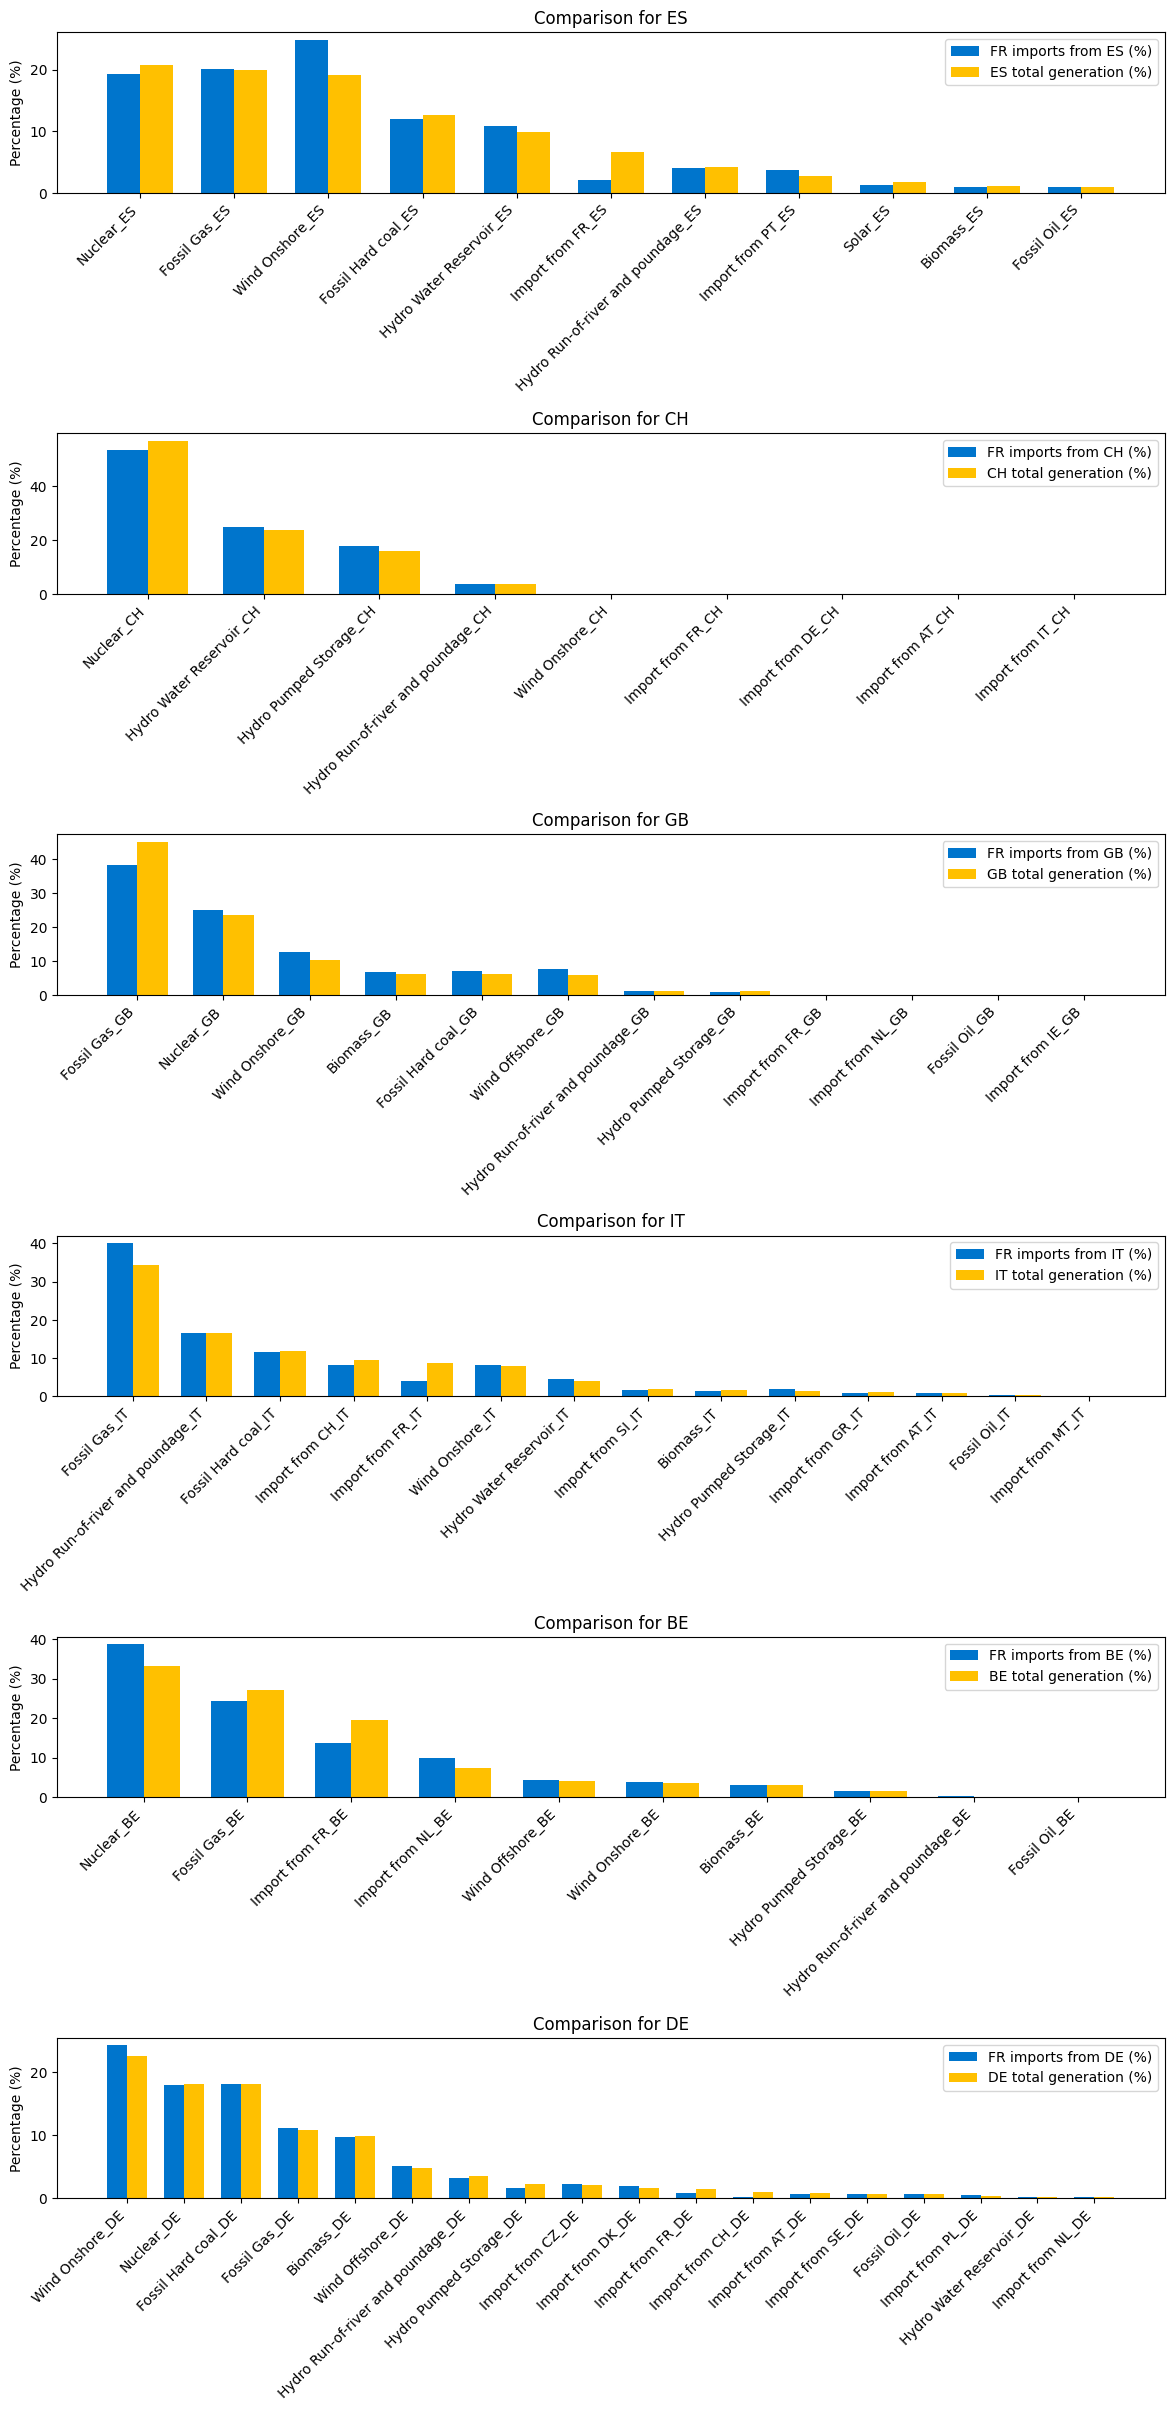

In [38]:
countries = ["FR", "ES", "CH", "GB", "IT", "BE", "DE"]

fig, axes = plt.subplots(len(countries), 1, figsize=(12, 4 * len(countries)), sharex=False)

for ax, country in zip(axes, countries):
    df_country = globals().get(f"df_comparison_{country}")
    if df_country is None:
        ax.set_visible(False)
        continue
    
    # Build the column names
    col_import = f"FR imports from {country} (%)"
    col_total = f"{country} total generation (%)"
    
    # Filter out rows where both columns are 0
    df_plot = df_country[(df_country[col_import] != 0) | (df_country[col_total] != 0)]
    
    if df_plot.empty:
        ax.set_visible(False)
        continue
    
    x = range(len(df_plot))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], df_plot[col_import], width=width, label=col_import, color="#0075CC")
    ax.bar([i + width/2 for i in x], df_plot[col_total], width=width, label=col_total, color="#FFC000")
    
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot.index, rotation=45, ha='right')
    ax.set_ylabel('Percentage (%)')
    ax.set_title(f'Comparison for {country}')
    ax.legend()

plt.tight_layout()
plt.show()


In [39]:
import pandas as pd

# List of neighboring countries
countries = ["DE", "ES", "IT", "GB", "BE", "CH"]  # example

all_diffs = []

for country_code in countries:
    # Load total generation of the country
    df_country = pd.read_pickle(f'df_total_consumption_{country_code}.pkl')
    df_country = df_country.copy()
    df_country.columns = [f"{col}_{country_code}" for col in df_country.columns]
    share_total = df_country.sum() / df_country.sum().sum() * 100

    # French imports from that country
    df_import = df_FR_total_consumption_neighbour_d.filter(regex=f'_{country_code}$')
    share_import = df_import.sum() / df_import.sum().sum() * 100

    # Combine into a comparison dataframe
    df_comparison = pd.DataFrame({
        "Import share (%)": share_import,
        "Generation share (%)": share_total
    }).fillna(0)

    # Exclude any technologies that are imports themselves
    df_comparison = df_comparison[~df_comparison.index.str.contains("import", case=False, na=False)]

    # Add difference column
    df_comparison["Difference (import - generation)"] = (
        df_comparison["Import share (%)"] - df_comparison["Generation share (%)"]
    )
    df_comparison["Country"] = country_code

    all_diffs.append(df_comparison)

# Concatenate all countries into one dataframe
df_all_imports_generation_differences = pd.concat(all_diffs)

# Remove country suffix (_XX) to get the technology name
df_all_imports_generation_differences["Technology"] = df_all_imports_generation_differences.index.str.replace(r"_..$", "", regex=True)

# Group by technology and calculate mean differences across countries
df_ranked_technology_differences_mean = df_all_imports_generation_differences.groupby("Technology").agg({
    "Difference (import - generation)": "mean",
    "Import share (%)": "mean",
    "Generation share (%)": "mean"
})

# Add absolute difference for ranking
df_ranked_technology_differences_mean["Abs difference (mean)"] = df_ranked_technology_differences_mean["Difference (import - generation)"].abs()

# Sort by absolute difference
df_ranked_technology_differences_mean = df_ranked_technology_differences_mean.sort_values("Abs difference (mean)", ascending=False)

df_ranked_technology_differences_mean.head(10)

,Difference (import - generation),Import share (%),Generation share (%),Abs difference (mean)
Technology,,,,
Wind Onshore,1.75975,12.3773,10.6176,1.75975
Hydro Water Reservoir,0.661438,10.1144,9.45297,0.661438
Fossil Gas,-0.617531,26.8296,27.4471,0.617531
Wind Offshore,0.601798,4.32635,3.72455,0.601798
Solar,-0.465972,1.24169,1.70766,0.465972
Nuclear,0.401251,30.9335,30.5322,0.401251
Hydro Pumped Storage,0.225583,4.70311,4.47752,0.225583
Hydro Run-of-river and poundage,-0.0522483,4.82935,4.88159,0.0522483
Fossil Oil,-0.0320458,0.420971,0.453017,0.0320458


# Technology renaming and redistribution according to ecoinvent shares

In [40]:
high_voltage_FR = agb.findActivity("market for electricity, high voltage", loc="FR", single=True, db_name=db_selected)
df_high_voltage_FR = agb.printAct(high_voltage_FR)
# Keep only the second level ("input", "amount", "unit")
df_high_voltage_FR.columns = df_high_voltage_FR.columns.droplevel(0)
df_high_voltage_FR

,input,amount,unit
Dinitrogen monoxide,Dinitrogen monoxide,N2O,kilogram
Ozone,Ozone,O3,kilogram
"electricity, high voltage","electricity production, deep geothermal[FR]",0.000204284,kilowatt hour
"electricity, high voltage#1","electricity production, hard coal[FR]",0.0134665,kilowatt hour
"electricity, high voltage#10","electricity production, wind, 1-3MW turbine, o...",0.0471622,kilowatt hour
"electricity, high voltage#11","electricity production, wind, <1MW turbine, on...",0.00303108,kilowatt hour
"electricity, high voltage#12","electricity production, wind, >3MW turbine, on...",0.000194832,kilowatt hour
"electricity, high voltage#13","electricity, high voltage, import from BE[FR]",0.00404687,kilowatt hour
"electricity, high voltage#14","electricity, high voltage, import from CH[FR]",0.00753638,kilowatt hour
"electricity, high voltage#15","electricity, high voltage, import from DE[FR]",0.00469589,kilowatt hour


In [41]:
df_high_voltage_FR_no_imports = df_high_voltage_FR[~df_high_voltage_FR["input"].str.contains("import", case=False, na=False)].copy()
df_high_voltage_FR_no_imports 

,input,amount,unit
Dinitrogen monoxide,Dinitrogen monoxide,N2O,kilogram
Ozone,Ozone,O3,kilogram
"electricity, high voltage","electricity production, deep geothermal[FR]",0.000204284,kilowatt hour
"electricity, high voltage#1","electricity production, hard coal[FR]",0.0134665,kilowatt hour
"electricity, high voltage#10","electricity production, wind, 1-3MW turbine, o...",0.0471622,kilowatt hour
"electricity, high voltage#11","electricity production, wind, <1MW turbine, on...",0.00303108,kilowatt hour
"electricity, high voltage#12","electricity production, wind, >3MW turbine, on...",0.000194832,kilowatt hour
"electricity, high voltage#19","heat and power co-generation, biogas, gas engi...",0.00132593,kilowatt hour
"electricity, high voltage#2","electricity production, hydro, pumped storage[FR]",0.00972603,kilowatt hour
"electricity, high voltage#20","heat and power co-generation, hard coal[RoW]",0.000496334,kilowatt hour


In [42]:
# All possible names each technology could have:

technology_groups = {
    "Nuclear": ["electricity production, nuclear, boiling water reactor", "electricity production, nuclear, pressure water reactor"],
    "Hydro Run-of-river and poundage": ["electricity production, hydro, run-of-river"],
    "Hydro Water Reservoir": ["electricity production, hydro, reservoir, alpine region", "electricity production, hydro, reservoir, non-alpine region"],
    "Hydro Pumped Storage": ["electricity production, hydro, pumped storage"],
    "Wind Onshore": ["electricity production, wind, 1-3MW turbine, onshore", "electricity production, wind, <1MW turbine, onshore", "electricity production, wind, >3MW turbine, onshore"],
    "Wind Offshore": ["electricity production, wind, 1-3MW turbine, offshore"],
    "Biomass": ["heat and power co-generation, biogas, gas engine", "heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014"],
    "Fossil Gas": ["electricity production, natural gas, combined cycle power plant", "electricity production, natural gas, conventional power plant", "heat and power co-generation, natural gas, conventional power plant, 100MW electrical"],
    "Fossil Hard coal": ["electricity production, hard coal", "heat and power co-generation, hard coal", "treatment of coal gas, in power plant", "treatment of blast furnace gas, in power plant"],
    "Fossil Oil": ["electricity production, oil", "heat and power co-generation, oil"],
    "Solar": ["electricity production, solar thermal parabolic trough, 50 MW", "electricity production, solar tower power plant, 20 MW"]
}

In [43]:
# Map country code to dataframe
ecoinvent_dfs = {
    "FR": df_high_voltage_FR_no_imports ,
    "ES": df_import_ES_EI,
    "CH": df_import_CH_EI,
    "GB": df_import_GB_EI,
    "IT": df_import_IT_EI,
    "BE": df_import_BE_EI,
    "DE": df_import_DE_EI
}

In [44]:
# Function created to disaggregate ENTSO-Es groups according to econinvent's distribution

def compute_shares(df, country_code):
    # Keep only proper electricity flows
    df_filtered = df[df["unit"] == "kilowatt hour"].copy()

    shares = {}
#do we need this? check
    if country_code == "FR":
        tech_groups = {k: v for k, v in technology_groups.items() if not k.startswith("Import from")}
    else:
        tech_groups = technology_groups

    # Iterate over umbrella groups
    for group_name, technologies in technology_groups.items():
        # Get rows that match any of the technologies in the group
        group_df = df_filtered[df_filtered["input"].str.contains("|".join(technologies), na=False)]
        total = group_df["amount"].sum()

        if total > 0:
            for _, row in group_df.iterrows():
                # remove country code or [RoW] if present
                base_name = row["input"].split("[")[0]
                var_name = base_name
                shares[var_name] = row["amount"] / total

    return shares
shares_map = {
    country: compute_shares(df, country)
    for country, df in ecoinvent_dfs.items()
}
shares_map

{'FR': {'electricity production, nuclear, pressure water reactor': 1.0,
  'electricity production, hydro, run-of-river': 1.0,
  'electricity production, hydro, reservoir, alpine region': 1.0,
  'electricity production, hydro, pumped storage': 1.0,
  'electricity production, wind, 1-3MW turbine, onshore': 0.9359787024889706,
  'electricity production, wind, <1MW turbine, onshore': 0.060154664904050685,
  'electricity production, wind, >3MW turbine, onshore': 0.003866632606978693,
  'electricity production, wind, 1-3MW turbine, offshore': 1.0,
  'heat and power co-generation, biogas, gas engine': 0.22413767077653843,
  'heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014': 0.7758623292234614,
  'heat and power co-generation, natural gas, conventional power plant, 100MW electrical': 0.2947811009389027,
  'electricity production, natural gas, combined cycle power plant': 0.5914661244926521,
  'electricity production, natural gas, conventional power plant': 0.1137527745

In [45]:
# Function created to execute the redistribution of ENTSO-E's technologies according to the shares obtained before (and also rename them):

def expand_activities(df, shares_map, technology_groups):
    new_df = pd.DataFrame(index=df.index)

    # Map umbrella group -> list of techs (inverted for fast lookup)
    tech_lookup = {}
    for group, techs in technology_groups.items():
        for tech in techs:
            tech_lookup[tech] = group

    for col in df.columns:
        if "_" not in col:
            # Columns without country suffix → keep unchanged
            new_df[col] = df[col]
            continue

        # Split into umbrella group and country code
        group, country = col.rsplit("_", 1)

        # Get the relevant shares for this country
        shares = shares_map.get(country, {})

        # Which technologies belong to this umbrella group?
        techs_for_group = technology_groups.get(group, [])

        # Filter shares for just these techs
        matching_shares = {tech: shares[tech] for tech in techs_for_group if tech in shares}

        if not matching_shares:
            # If no mapping, just copy the column as is
            new_df[col] = df[col]
            continue

        # If only one share == 1 → just rename
        if len(matching_shares) == 1 and list(matching_shares.values())[0] == 1:
            tech = list(matching_shares.keys())[0]
            new_col_name = f"{tech}_{country}"
            new_df[new_col_name] = df[col]
        else:
            # Split column into multiple according to shares
            for tech, share in matching_shares.items():
                new_col_name = f"{tech}_{country}"
                new_df[new_col_name] = df[col] * share

    return new_df

In [46]:
# Apply transformation to the dynamic df

df_FR_total_consumption_ei_match_d = expand_activities(
    df_FR_total_consumption_neighbour_d,
    shares_map,
    technology_groups
)
df_FR_total_consumption_ei_match_d

,"electricity production, nuclear, pressure water reactor_FR","electricity production, hydro, run-of-river_FR","electricity production, hydro, reservoir, alpine region_FR","electricity production, wind, 1-3MW turbine, onshore_FR","electricity production, wind, <1MW turbine, onshore_FR","electricity production, wind, >3MW turbine, onshore_FR","electricity production, hydro, pumped storage_FR","heat and power co-generation, biogas, gas engine_FR","heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014_FR","electricity production, natural gas, combined cycle power plant_FR",...,"heat and power co-generation, biogas, gas engine_ES","heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014_ES","electricity production, natural gas, combined cycle power plant_ES","electricity production, natural gas, conventional power plant_ES","electricity production, hard coal_ES","treatment of coal gas, in power plant_ES","treatment of blast furnace gas, in power plant_ES","electricity production, oil_ES","electricity, high voltage, import from FR_ES","electricity, high voltage, import from PT_ES"
2018-01-01 00:00:00,"32,627.3","5,117.45","1,969.06","8,055.32",517.71,33.2774,0,58.0194,200.837,"1,196.29",...,0.536488,4.41897,59.1017,1.89252,16.8592,0.0533163,0.589753,3.40907,15.3725,0
2018-01-01 01:00:00,"30,314.3","5,041.21","1,881.96","7,916.02",508.757,32.702,0,57.2188,198.065,"1,193.51",...,0.15209,1.25274,16.1815,0.518153,4.71903,0.0149237,0.165077,0.975719,4.22982,0
2018-01-01 02:00:00,"30,006.6","4,898.2","1,375.84","7,788.84",500.583,32.1766,0,57.5141,199.088,"1,184.13",...,0.0826749,0.68098,9.42518,0.301808,2.68308,0.00848509,0.0938571,0.52467,1.21663,0
2018-01-01 03:00:00,"28,433.4","4,594.43","1,100.43","7,252.78",466.131,29.962,0,54.9767,190.304,"1,130.01",...,0.0141706,0.116721,1.57397,0.0504008,0.473035,0.00149595,0.0165473,0.089929,1.31833,0
2018-01-01 04:00:00,"27,619.3","4,260.77",570.964,"6,826.05",438.705,28.1992,0,53.3681,184.736,"1,097.42",...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-30 19:00:00,"48,054.1","4,317.24","1,381.52","1,501.34",96.4902,6.20222,"1,717.44",65.6658,227.305,"1,929.99",...,0.30707,2.52929,59.2032,1.89577,15.5095,0.0490481,0.542541,2.43116,36.4941,24.9578
2018-12-30 20:00:00,"47,711.7","4,141.78","1,258.1","1,433.93",92.1573,5.9237,"1,160.28",65.0154,225.054,"1,878.67",...,0.0540733,0.445393,10.0014,0.32026,2.72224,0.00860894,0.0952269,0.401389,6.18067,4.80668
2018-12-30 21:00:00,"47,745.8","3,803.62","1,143.56","1,436.95",92.352,5.93622,308.241,65.0804,225.279,"1,902.71",...,0,0,0,0,0,0,0,0,0,0
2018-12-30 22:00:00,"48,170.8","3,765.07","1,114.78","1,431.56",92.0053,5.91394,496.607,66.0893,228.771,"1,914.32",...,0,0,0,0,0,0,0,0,0,0


In [47]:
# Apply transformation to the yearly aerage df:
df_FR_total_consumption_ei_match_y = expand_activities(
    df_FR_total_consumption_neighbour_y,
    shares_map,
    technology_groups
)
df_FR_total_consumption_ei_match_y

,"electricity production, nuclear, pressure water reactor_FR","electricity production, hydro, run-of-river_FR","electricity production, hydro, reservoir, alpine region_FR","electricity production, wind, 1-3MW turbine, onshore_FR","electricity production, wind, <1MW turbine, onshore_FR","electricity production, wind, >3MW turbine, onshore_FR","electricity production, hydro, pumped storage_FR","heat and power co-generation, biogas, gas engine_FR","heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014_FR","electricity production, natural gas, combined cycle power plant_FR",...,"heat and power co-generation, biogas, gas engine_ES","heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014_ES","electricity production, natural gas, combined cycle power plant_ES","electricity production, natural gas, conventional power plant_ES","electricity production, hard coal_ES","treatment of coal gas, in power plant_ES","treatment of blast furnace gas, in power plant_ES","electricity production, oil_ES","electricity, high voltage, import from FR_ES","electricity, high voltage, import from PT_ES"
2018-01-01 00:00:00,"32,627.3","5,117.45","1,969.06","8,055.32",517.71,33.2774,0,58.0194,200.837,"1,196.29",...,0.603875,4.97402,93.2912,2.98731,58.9271,0.186354,2.06134,4.67397,31.8035,13.3695
2018-01-01 01:00:00,"30,314.3","5,041.21","1,881.96","7,916.02",508.757,32.702,0,57.2188,198.065,"1,193.51",...,0.163529,1.34696,25.2632,0.808964,15.9575,0.0504646,0.55821,1.26571,8.61238,3.62045
2018-01-01 02:00:00,"30,006.6","4,898.2","1,375.84","7,788.84",500.583,32.1766,0,57.5141,199.088,"1,184.13",...,0.0821866,0.676958,12.6968,0.40657,8.01991,0.0253626,0.280545,0.636122,4.32842,1.81957
2018-01-01 03:00:00,"28,433.4","4,594.43","1,100.43","7,252.78",466.131,29.962,0,54.9767,190.304,"1,130.01",...,0.0135709,0.111781,2.09653,0.0671338,1.32427,0.00418793,0.0463244,0.105038,0.714719,0.300452
2018-01-01 04:00:00,"27,619.3","4,260.77",570.964,"6,826.05",438.705,28.1992,0,53.3681,184.736,"1,097.42",...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-30 19:00:00,"48,054.1","4,317.24","1,381.52","1,501.34",96.4902,6.20222,"1,717.44",65.6658,227.305,"1,929.99",...,0.39077,3.21871,60.3692,1.93311,38.1321,0.120591,1.3339,3.02455,20.5802,8.65147
2018-12-30 20:00:00,"47,711.7","4,141.78","1,258.1","1,433.93",92.1573,5.9237,"1,160.28",65.0154,225.054,"1,878.67",...,0.0680135,0.560217,10.5073,0.336457,6.63688,0.0209888,0.232165,0.526423,3.58198,1.50579
2018-12-30 21:00:00,"47,745.8","3,803.62","1,143.56","1,436.95",92.352,5.93622,308.241,65.0804,225.279,"1,902.71",...,0,0,0,0,0,0,0,0,0,0
2018-12-30 22:00:00,"48,170.8","3,765.07","1,114.78","1,431.56",92.0053,5.91394,496.607,66.0893,228.771,"1,914.32",...,0,0,0,0,0,0,0,0,0,0


# 1.8 French + Neighbors Analisys

In [48]:
# Check if everything went well:
list(df_FR_total_consumption_ei_match_d.columns)

['electricity production, nuclear, pressure water reactor_FR',
 'electricity production, hydro, run-of-river_FR',
 'electricity production, hydro, reservoir, alpine region_FR',
 'electricity production, wind, 1-3MW turbine, onshore_FR',
 'electricity production, wind, <1MW turbine, onshore_FR',
 'electricity production, wind, >3MW turbine, onshore_FR',
 'electricity production, hydro, pumped storage_FR',
 'heat and power co-generation, biogas, gas engine_FR',
 'heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014_FR',
 'electricity production, natural gas, combined cycle power plant_FR',
 'electricity production, natural gas, conventional power plant_FR',
 'heat and power co-generation, natural gas, conventional power plant, 100MW electrical_FR',
 'electricity production, hard coal_FR',
 'heat and power co-generation, hard coal_FR',
 'treatment of blast furnace gas, in power plant_FR',
 'electricity production, oil_FR',
 'heat and power co-generation, oil_FR',
 'ele

In [49]:
# Verify if d and y are the same
list(df_FR_total_consumption_ei_match_d.columns) == list(df_FR_total_consumption_ei_match_y.columns)

True

In [50]:
# Verify if values have changed
total_FR_d=df_FR_total_consumption_ei_match_d.sum().sum()
round(total_FR_d,2)== round(france_final_total,2)

True

In [51]:
# Verify if values have changed
total_FR_y=df_FR_total_consumption_ei_match_y.sum().sum()
round(total_FR_y,2)== round(france_final_total,2)

True

In [52]:
# Sum all hourly values for each technology (each column) over the whole year for d
france_yearly_total_d = df_FR_total_consumption_ei_match_d.sum(axis=0)
france_yearly_total_d

electricity production, nuclear, pressure water reactor_FR    3.2263e+08
electricity production, hydro, run-of-river_FR               3.51143e+07
electricity production, hydro, reservoir, alpine region_FR   1.47228e+07
electricity production, wind, 1-3MW turbine, onshore_FR      2.07317e+07
electricity production, wind, <1MW turbine, onshore_FR       1.33241e+06
                                                                 ...    
treatment of coal gas, in power plant_ES                        1,264.08
treatment of blast furnace gas, in power plant_ES               13,982.5
electricity production, oil_ES                                    31,462
electricity, high voltage, import from FR_ES                    74,698.2
electricity, high voltage, import from PT_ES                     130,649
Length: 132, dtype: float64

In [53]:
# Sum all hourly values for each technology (each column) over the whole year for y
france_yearly_total_y = df_FR_total_consumption_ei_match_y.sum(axis=0)
france_yearly_total_y

electricity production, nuclear, pressure water reactor_FR    3.2263e+08
electricity production, hydro, run-of-river_FR               3.51143e+07
electricity production, hydro, reservoir, alpine region_FR   1.47228e+07
electricity production, wind, 1-3MW turbine, onshore_FR      2.07317e+07
electricity production, wind, <1MW turbine, onshore_FR       1.33241e+06
                                                                 ...    
treatment of coal gas, in power plant_ES                        1,340.98
treatment of blast furnace gas, in power plant_ES               14,833.1
electricity production, oil_ES                                  33,633.2
electricity, high voltage, import from FR_ES                     228,853
electricity, high voltage, import from PT_ES                    96,204.8
Length: 132, dtype: float64

In [54]:
# Calculate proportions relative to total yearly production across all technologies for d
france_yearly_proportions_d = france_yearly_total_d/ total_FR_d
france_yearly_proportions_d

electricity production, nuclear, pressure water reactor_FR      0.707495
electricity production, hydro, run-of-river_FR                 0.0770019
electricity production, hydro, reservoir, alpine region_FR     0.0322855
electricity production, wind, 1-3MW turbine, onshore_FR        0.0454623
electricity production, wind, <1MW turbine, onshore_FR        0.00292183
                                                                 ...    
treatment of coal gas, in power plant_ES                     2.77199e-06
treatment of blast furnace gas, in power plant_ES            3.06621e-05
electricity production, oil_ES                               6.89928e-05
electricity, high voltage, import from FR_ES                 0.000163805
electricity, high voltage, import from PT_ES                   0.0002865
Length: 132, dtype: float64

In [55]:
# Calculate proportions relative to total yearly production across all technologies for y
france_yearly_proportions_y = france_yearly_total_y/ total_FR_y
france_yearly_proportions_y

electricity production, nuclear, pressure water reactor_FR      0.707495
electricity production, hydro, run-of-river_FR                 0.0770019
electricity production, hydro, reservoir, alpine region_FR     0.0322855
electricity production, wind, 1-3MW turbine, onshore_FR        0.0454623
electricity production, wind, <1MW turbine, onshore_FR        0.00292183
                                                                 ...    
treatment of coal gas, in power plant_ES                     2.94062e-06
treatment of blast furnace gas, in power plant_ES            3.25274e-05
electricity production, oil_ES                               7.37541e-05
electricity, high voltage, import from FR_ES                 0.000501851
electricity, high voltage, import from PT_ES                 0.000210967
Length: 132, dtype: float64

# 2 ELMAS

In [56]:
# Load the ELMAS dataset 
elmas_path = r"C:\Users\jsteinbach\OneDrive - Université Paris Sciences et Lettres\PHD\ELMAS_dataset\ELMAS_dataset\Time_series_18_clusters.csv"
#https://figshare.com/articles/dataset/ELMAS_dataset/23889780?utm_source=chatgpt.com&file=41895786
df_elmas = pd.read_csv(elmas_path, sep=";", parse_dates=["Time"])
df_elmas.set_index("Time", inplace=True)
df_elmas = df_elmas.map(lambda x: str(x).replace(',', '.'))
df_elmas = df_elmas.apply(pd.to_numeric, errors='coerce').fillna(0)

In [57]:
df_elmas

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
Time,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,"121,484","15,063.7","48,659.2","38,340.2","36,853.1","22,481.7","25,379.9","46,769.8","19,430.1","230,629","64,673.3","23,206","32,158.6","56,522.5","27,040.9","81,045.2","27,234.4","15,689.6"
2018-01-01 01:00:00,"121,662","15,246.7","49,506.4","37,925.1","36,666.6","18,709.7","25,151.9","44,355.8","18,739.1","232,097","64,995.9","23,752.1","32,142.7","58,466.9","25,821.4","80,044.6","26,885.1","16,076.3"
2018-01-01 02:00:00,"122,048","15,372.8","50,884.4","37,752.2","37,042.7","16,965.7","25,109.3","42,534.6","18,342","236,371","64,254.4","23,940.1","30,837.9","60,183.7","25,284.3","79,790.9","27,091.8","16,036.9"
2018-01-01 03:00:00,"122,704","15,717","51,545.6","37,036.9","37,002.1","16,773.5","25,214","42,076.4","18,221.1","239,913","64,843.8","23,894.2","30,203.8","63,491.3","25,257.5","78,790.1","27,277.9","16,380.7"
2018-01-01 04:00:00,"124,765","16,386.7","57,763.1","36,766.4","37,851.4","18,984.3","27,187","41,461.5","18,376.6","251,853","64,929.6","24,073.5","30,122.1","67,718.1","25,481.9","79,944.2","27,763.8","16,701.5"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-30 19:00:00,"114,115","16,489.7","50,491.4","37,898.2","36,698","25,201.9","29,716.8","42,505.4","26,353.7","203,809","64,067","20,970.4","36,671.1","43,196.7","20,279.8","93,111.5","26,927.3","14,704.3"
2018-12-30 20:00:00,"114,787","15,363.7","50,247.9","37,430","36,737.5","24,925","29,172.5","46,212.2","25,952.4","206,995","63,978.3","21,356.6","37,366","44,041.2","20,955.9","86,751.2","25,494.5","14,719.6"
2018-12-30 21:00:00,"115,381","14,816.9","49,228.8","37,397.7","36,311.1","23,831.4","28,331.2","46,220.9","24,974.7","210,840","63,633.9","21,488.1","35,373.7","45,587.9","19,971.4","83,202.6","24,787.2","14,628.7"


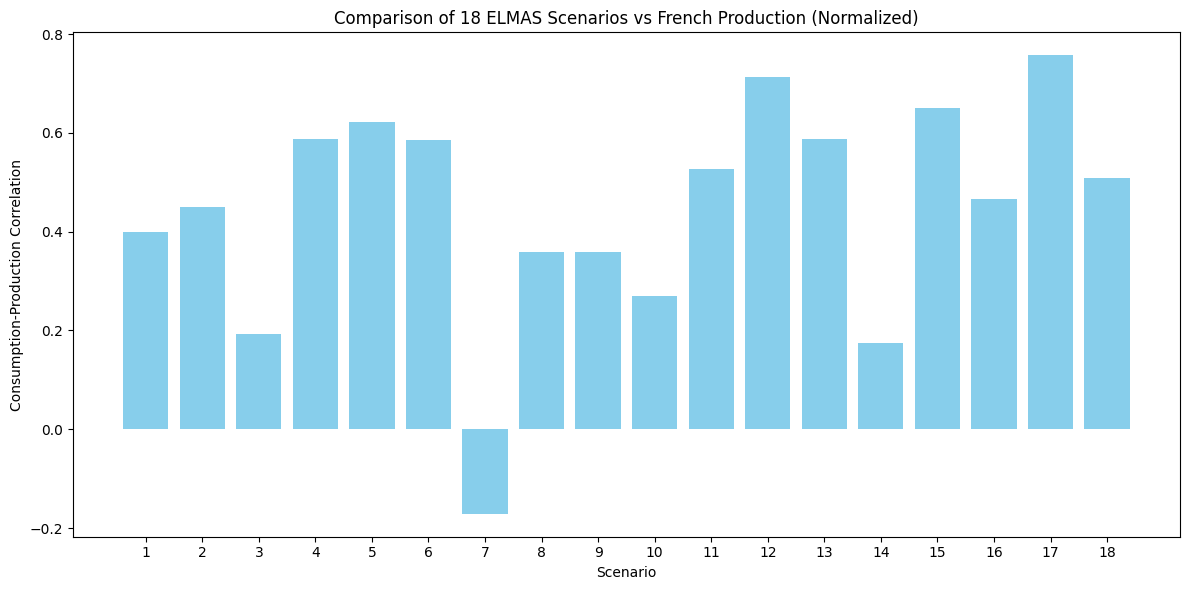

In [58]:
# This script compares 18 ELMAS consumption scenarios with French electricity production.
# Blue bars = Correlation of each ELMAS scenario with French electricity production (normalized). 
# - Positive correlation (close to 1) means the scenario consumes electricity when production is high (aligned).
# - Zero correlation means no clear relationship.
# - Negative correlation means the scenario consumes more when production is low (opposite alignment), which can indicate higher potential impact.

# Normalize ELMAS scenarios (0-1)
df_elmas_norm = (df_elmas - df_elmas.min()) / (df_elmas.max() - df_elmas.min())

# Normalize total French production (sum of all columns) (0-1)
df_FR_sum = df_FR_total_consumption_final.sum(axis=1)
df_FR_norm = (df_FR_sum - df_FR_sum.min()) / (df_FR_sum.max() - df_FR_sum.min())

# Calculate correlation with production
correlations = df_elmas_norm.corrwith(df_FR_norm)

# Plot comparison
fig, ax1 = plt.subplots(figsize=(12,6))

# Blue bars: correlation
ax1.bar(correlations.index, correlations.values, color='skyblue', label='Correlation with Production')
ax1.set_xlabel('Scenario')
ax1.set_ylabel('Consumption-Production Correlation')

# Title and layout
plt.title('Comparison of 18 ELMAS Scenarios vs French Production (Normalized)')
fig.tight_layout()
plt.show()


In [59]:
# Calculate consumption per scenario per year:
elmas_yearly_totals = df_elmas.sum().to_frame(name='Total Consumption')

# Scenario names mapping
scenario_names = [
    "Manufacturing processes", "Trades (non food)", "Trades (food)", "Education",
    "Office", "Crop farming and transportation", "Livestock farming",
    "Water supply and telecommunications", "Restaurants", "Food industry",
    "Wine industry", "Energy supply and rental activities", "Hotels",
    "Bakery", "Property management companies", "Hospital",
    "Recreational and social activities", "Construction"
]

elmas_yearly_totals['Scenario'] = scenario_names

elmas_total = elmas_yearly_totals['Total Consumption'].sum()

# Add a percentage column
elmas_yearly_totals['Percentage'] = (elmas_yearly_totals['Total Consumption'] / elmas_total) * 100

elmas_yearly_totals

,Total Consumption,Scenario,Percentage
1,1.98388e+09,Manufacturing processes,18.472
2,2.02286e+08,Trades (non food),1.8835
3,6.38249e+08,Trades (food),5.94278
4,4.19233e+08,Education,3.90351
5,3.68506e+08,Office,3.43119
6,2.65065e+08,Crop farming and transportation,2.46804
7,3.40516e+08,Livestock farming,3.17057
8,4.55941e+08,Water supply and telecommunications,4.2453
9,2.21265e+08,Restaurants,2.06021
10,2.54432e+09,Food industry,23.6903


In [60]:
elmas_total_MWh = elmas_total/1_000
elmas_total_MWh, FR_2018_load

(10739897.417523488, 456018188.46999997)

In [61]:
# Elmas has covered this percentage of the electricity consumed in France:
share_elmas_in_FR = elmas_total_MWh*100/FR_2018_load
share_elmas_in_FR 

2.355146722010636

# 2.1 Static data

In [62]:
# Create a new DataFrame to store yearly distributed consumption per scenario and technology
yearly_distributed = pd.DataFrame()

for scenario in elmas_yearly_totals.index:
    # Multiply the total yearly consumption of the scenario by the France proportions
    yearly_distributed[scenario] = france_yearly_proportions_y * elmas_yearly_totals['Total Consumption'][scenario]

# Transpose if you want scenarios as rows and technologies as columns
yearly_distributed = yearly_distributed.T
yearly_distributed 

,"electricity production, nuclear, pressure water reactor_FR","electricity production, hydro, run-of-river_FR","electricity production, hydro, reservoir, alpine region_FR","electricity production, wind, 1-3MW turbine, onshore_FR","electricity production, wind, <1MW turbine, onshore_FR","electricity production, wind, >3MW turbine, onshore_FR","electricity production, hydro, pumped storage_FR","heat and power co-generation, biogas, gas engine_FR","heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014_FR","electricity production, natural gas, combined cycle power plant_FR",...,"heat and power co-generation, biogas, gas engine_ES","heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014_ES","electricity production, natural gas, combined cycle power plant_ES","electricity production, natural gas, conventional power plant_ES","electricity production, hard coal_ES","treatment of coal gas, in power plant_ES","treatment of blast furnace gas, in power plant_ES","electricity production, oil_ES","electricity, high voltage, import from FR_ES","electricity, high voltage, import from PT_ES"
1,1.40358e+09,1.52762e+08,6.40505e+07,9.01917e+07,5.79655e+06,"372,592",2.00954e+07,2.79362e+06,9.67023e+06,6.54163e+07,...,"18,904.3","155,712",2.92049e+06,"93,518.1",1.84472e+06,"5,833.83","64,530.3","146,319","995,610","418,533"
2,1.43117e+08,1.55764e+07,6.53092e+06,9.19641e+06,"591,047","37,991.4",2.04903e+06,"284,852","986,027",6.67018e+06,...,"1,927.58","15,877.2","297,788","9,535.59","188,097",594.847,"6,579.84","14,919.4","101,518","42,675.7"
3,4.51558e+08,4.91464e+07,2.06062e+07,2.90163e+07,1.86486e+06,"119,870",6.46505e+06,"898,757",3.11109e+06,2.10456e+07,...,"6,081.86","50,095.3","939,573","30,086.4","593,479","1,876.85","20,760.6","47,073.5","320,306","134,649"
4,2.96605e+08,3.22817e+07,1.35351e+07,1.90593e+07,1.22493e+06,"78,736.1",4.24656e+06,"590,347",2.04351e+06,1.38238e+07,...,"3,994.86","32,905","617,157","19,762.2","389,825","1,232.8","13,636.5","30,920.1","210,392","88,444.3"
5,2.60716e+08,2.83757e+07,1.18974e+07,1.67531e+07,1.07671e+06,"69,209.1",3.73273e+06,"518,916",1.79625e+06,1.21511e+07,...,"3,511.49","28,923.6","542,482","17,371","342,657","1,083.64","11,986.5","27,178.8","184,935","77,742.6"
6,1.87532e+08,2.04105e+07,8.55776e+06,1.20505e+07,"774,475","49,781.9",2.68494e+06,"373,254",1.29204e+06,8.74024e+06,...,"2,525.8","20,804.6","390,205","12,494.9","246,472",779.455,"8,621.87","19,549.6","133,023","55,920"
7,2.40913e+08,2.62204e+07,1.09937e+07,1.54806e+07,"994,929","63,952.2",3.4492e+06,"479,501",1.65981e+06,1.12281e+07,...,"3,244.77","26,726.6","501,276","16,051.6","316,630","1,001.33","11,076.1","25,114.4","170,888","71,837.5"
8,3.22576e+08,3.51083e+07,1.47203e+07,2.07281e+07,1.33218e+06,"85,630.3",4.61839e+06,"642,039",2.22244e+06,1.50342e+07,...,"4,344.65","35,786.2","671,196","21,492.6","423,959","1,340.75","14,830.6","33,627.5","228,814","96,188.5"
9,1.56544e+08,1.70378e+07,7.14366e+06,1.00592e+07,"646,499","41,555.8",2.24127e+06,"311,577",1.07854e+06,7.29598e+06,...,"2,108.43","17,366.8","325,726","10,430.2","205,744",650.656,"7,197.17","16,319.2","111,042","46,679.6"
10,1.80009e+09,1.95917e+08,8.21446e+07,1.15671e+08,7.43406e+06,"477,848",2.57723e+07,3.58281e+06,1.2402e+07,8.38962e+07,...,"24,244.7","199,700",3.74551e+06,"119,937",2.36584e+06,"7,481.86","82,759.9","187,654",1.27687e+06,"536,767"


# 2.2 Dynamic data

In [63]:
# select a scenario
scenario = df_elmas.columns[0]

# Calculate the total production in FR
total_production = df_FR_total_consumption_ei_match_d.sum(axis=1)

# Atribute a proportion to each technology, this proportion will be applied to elmas data
proportions = df_FR_total_consumption_ei_match_d.div(total_production, axis=0).fillna(0)

# consumption per hour in elmas is:
consumption_scenario = df_elmas[scenario]

# Distribute the proportions to every hour:
df_scenario_tech = proportions.multiply(consumption_scenario, axis=0)

print(df_scenario_tech.head())

In [64]:
df_scenario_tech.sum(axis=1).head() # verifying if the sum of all columns is equal to the original elmas df scenario

2018-01-01 00:00:00   121,484
2018-01-01 01:00:00   121,662
2018-01-01 02:00:00   122,048
2018-01-01 03:00:00   122,704
2018-01-01 04:00:00   124,765
dtype: float64

In [65]:
consumption_scenario.head()  # yes it is!

Time
2018-01-01 00:00:00   121,484
2018-01-01 01:00:00   121,662
2018-01-01 02:00:00   122,048
2018-01-01 03:00:00   122,704
2018-01-01 04:00:00   124,765
Name: 1, dtype: float64

In [66]:
df_elmas.index

DatetimeIndex(['2018-01-01 00:00:00', '2018-01-01 01:00:00',
               '2018-01-01 02:00:00', '2018-01-01 03:00:00',
               '2018-01-01 04:00:00', '2018-01-01 05:00:00',
               '2018-01-01 06:00:00', '2018-01-01 07:00:00',
               '2018-01-01 08:00:00', '2018-01-01 09:00:00',
               ...
               '2018-12-30 14:00:00', '2018-12-30 15:00:00',
               '2018-12-30 16:00:00', '2018-12-30 17:00:00',
               '2018-12-30 18:00:00', '2018-12-30 19:00:00',
               '2018-12-30 20:00:00', '2018-12-30 21:00:00',
               '2018-12-30 22:00:00', '2018-12-30 23:00:00'],
              dtype='datetime64[ns]', name='Time', length=8736, freq=None)

In [67]:
# Apply what was done before to all scenatios to build a new df:
results = {}

for scenario in df_elmas.columns:
    consumption_scenario = df_elmas[scenario]
    df_scenario_tech = proportions.multiply(consumption_scenario, axis=0)
    results[scenario] = df_scenario_tech


In [68]:
# Create a dictionary to store sums per scenario
total_per_scenario = {}

for scenario_name, df_scenario in results.items():
    # Sum over all rows (time) for each technology (column)
    total_per_scenario[scenario_name] = df_scenario.sum(axis=0)

# Convert dictionary to a DataFrame: scenarios as rows, technologies as columns
dynamic_df = pd.DataFrame(total_per_scenario).T  #transpose
dynamic_df

,"electricity production, nuclear, pressure water reactor_FR","electricity production, hydro, run-of-river_FR","electricity production, hydro, reservoir, alpine region_FR","electricity production, wind, 1-3MW turbine, onshore_FR","electricity production, wind, <1MW turbine, onshore_FR","electricity production, wind, >3MW turbine, onshore_FR","electricity production, hydro, pumped storage_FR","heat and power co-generation, biogas, gas engine_FR","heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014_FR","electricity production, natural gas, combined cycle power plant_FR",...,"heat and power co-generation, biogas, gas engine_ES","heat and power co-generation, wood chips, 6667 kW, state-of-the-art 2014_ES","electricity production, natural gas, combined cycle power plant_ES","electricity production, natural gas, conventional power plant_ES","electricity production, hard coal_ES","treatment of coal gas, in power plant_ES","treatment of blast furnace gas, in power plant_ES","electricity production, oil_ES","electricity, high voltage, import from FR_ES","electricity, high voltage, import from PT_ES"
1,1.41217e+09,1.55107e+08,6.44563e+07,8.68017e+07,5.57868e+06,"358,587",2.04797e+07,2.86614e+06,9.92127e+06,6.31422e+07,...,"16,067.9","132,349",2.87505e+06,"92,063.1",1.69654e+06,"5,365.22","59,346.9","133,413","326,624","553,560"
2,1.43228e+08,1.57423e+07,6.69085e+06,8.79869e+06,"565,485","36,348.4",2.3004e+06,"286,908","993,145",6.67346e+06,...,"1,707.09","14,061","311,857","9,986.09","182,711",577.815,"6,391.44","14,150.7","35,132","60,039.9"
3,4.55048e+08,4.98195e+07,2.07377e+07,2.75778e+07,1.77241e+06,"113,927",6.79512e+06,"923,065",3.19523e+06,2.00732e+07,...,"5,176.02","42,634.1","934,464","29,922.8","550,686","1,741.52","19,263.6","42,526","109,321","177,607"
4,2.96157e+08,3.24363e+07,1.37681e+07,1.8779e+07,1.20691e+06,"77,578.2",4.68504e+06,"590,566",2.04427e+06,1.40437e+07,...,"3,649.73","30,062.2","665,553","21,312","388,344","1,228.12","13,584.7","30,364","71,966.3","130,430"
5,2.62144e+08,2.86638e+07,1.18943e+07,1.63413e+07,1.05025e+06,"67,507.9",3.80428e+06,"528,237",1.82852e+06,1.17461e+07,...,"2,977.01","24,521.2","531,225","17,010.6","311,940",986.494,"10,912","24,496.8","60,751.5","102,609"
6,1.87809e+08,2.05116e+07,8.7296e+06,1.17055e+07,"752,303","48,356.7",2.93844e+06,"377,361",1.30625e+06,8.68989e+06,...,"2,263.43","18,643.5","408,077","13,067.2","239,134",756.25,"8,365.19","18,690.2","46,092.6","80,364.9"
7,2.43778e+08,2.72328e+07,1.11034e+07,1.45851e+07,"937,374","60,252.7",3.39296e+06,"502,852",1.74064e+06,1.00559e+07,...,"2,500.75","20,598.3","434,329","13,907.8","253,688",802.275,"8,874.29","20,469.7","53,997.1","86,343"
8,3.25378e+08,3.56844e+07,1.4657e+07,2.00312e+07,1.28739e+06,"82,751.3",4.57159e+06,"661,499",2.28981e+06,1.41391e+07,...,"3,537.73","29,139.7","629,123","20,145.4","370,473","1,171.6","12,959.6","29,055.3","73,803.9","120,422"
9,1.57465e+08,1.73598e+07,7.2256e+06,9.72534e+06,"625,040","40,176.5",2.34101e+06,"319,234",1.10504e+06,6.9074e+06,...,"1,734.91","14,290.1","309,432","9,908.44","181,051",572.564,"6,333.37","14,184.5","36,511.3","59,867.9"
10,1.81599e+09,1.98661e+08,8.17115e+07,1.11448e+08,7.16266e+06,"460,402",2.57877e+07,3.68006e+06,1.27387e+07,7.95749e+07,...,"20,147.4","165,951",3.60643e+06,"115,483",2.13622e+06,"6,755.7","74,727.5","165,999","420,160","682,958"


In [69]:
# Verify if all dfs contain the same figures

dynamic_df.sum(axis=1),yearly_distributed.sum(axis=1), elmas_yearly_totals['Total Consumption']

(1    1.98388e+09
 2    2.02286e+08
 3    6.38249e+08
 4    4.19233e+08
 5    3.68506e+08
 6    2.65065e+08
 7    3.40516e+08
 8    4.55941e+08
 9    2.21265e+08
 10   2.54432e+09
 11   6.97628e+08
 12   1.99204e+08
 13   2.90618e+08
 14   6.98769e+08
 15   1.88334e+08
 16   8.13747e+08
 17    2.5166e+08
 18   1.60683e+08
 dtype: float64,
 1    1.98388e+09
 2    2.02286e+08
 3    6.38249e+08
 4    4.19233e+08
 5    3.68506e+08
 6    2.65065e+08
 7    3.40516e+08
 8    4.55941e+08
 9    2.21265e+08
 10   2.54432e+09
 11   6.97628e+08
 12   1.99204e+08
 13   2.90618e+08
 14   6.98769e+08
 15   1.88334e+08
 16   8.13747e+08
 17    2.5166e+08
 18   1.60683e+08
 dtype: float64,
 1    1.98388e+09
 2    2.02286e+08
 3    6.38249e+08
 4    4.19233e+08
 5    3.68506e+08
 6    2.65065e+08
 7    3.40516e+08
 8    4.55941e+08
 9    2.21265e+08
 10   2.54432e+09
 11   6.97628e+08
 12   1.99204e+08
 13   2.90618e+08
 14   6.98769e+08
 15   1.88334e+08
 16   8.13747e+08
 17    2.5166e+08
 18   1.6068

# 2.3 Dynamic (ecoinvent match) x Static (market for electricity, high voltage FR)

In [70]:
# Transmission activities *to de added

high_trans = agb.findActivity("market for transmission network, electricity, high voltage", loc="GLO", single=False, db_name=db_selected)
high_trans_long = agb.findActivity("transmission network construction, long-distance", loc="UCTE", single=False, db_name=db_selected)
#high_trans_long_39 = agb.findActivity("transmission network construction, electricity, high voltage", loc="CH", single=False, db_name=db_selected)

In [71]:
# Function created to create activities instead of writing each individually:

def create_activities_from_df(df, agb, db_selected, country):
    activities = {}
    country_suffix = f"_{country}"
    cols = [c for c in df.columns if c.endswith(country_suffix)]

    for col in cols:
        base_name = col.rsplit("_", 1)[0].strip()

        # Check if this is a hydro pumped storage or other grouped tech
        found_tech = None
        for group, tech_list in technology_groups.items():
            # If base_name contains the group name, pick the first matching detailed tech
            if group in base_name:
                found_tech = tech_list[0]  # could iterate if multiple needed
                break

        # Use found tech or fallback to base_name
        activity_search_name = found_tech if found_tech else base_name

        # Special rule for CH imports * CH in ecoinvent is different from others but since we are using entso-es data it will be adapted
        if country == "CH" and base_name.startswith("electricity, high voltage, import from"):
            source = base_name.split("import from")[1].strip()
            market_name = f"market for electricity, high voltage"
            try:
                act = agb.findActivity(
                    market_name,
                    loc=source,
                    single=False,
                    db_name=db_selected,
                    unit='kilowatt hour'
                )
            except Exception:
                act = []
        else:
            # normal search: first try country
            act = agb.findActivity(
                activity_search_name,
                loc=country,
                single=False,
                db_name=db_selected,
                unit='kilowatt hour'
            )
            # fallback to RoW >> heat from coal activity in FR is RoW
            if not act:
                act = agb.findActivity(
                    activity_search_name,
                    loc="RoW",
                    single=False,
                    db_name=db_selected,
                    unit='kilowatt hour'
                )

        activities[col] = act

    return activities

In [72]:
# Generate activities for d:

countries = set(c.rsplit("_", 1)[1] for c in df_FR_total_consumption_ei_match_d.columns if "_" in c)

activities = {
    country: create_activities_from_df(df_FR_total_consumption_ei_match_d, agb, db_selected, country)
    for country in countries
}
activities

{'BE': {'electricity production, nuclear, pressure water reactor_BE': 'electricity production, nuclear, pressure water reactor' (kilowatt hour, BE, None),
  'electricity production, hydro, run-of-river_BE': 'electricity production, hydro, run-of-river' (kilowatt hour, BE, None),
  'electricity production, hydro, pumped storage_BE': 'electricity production, hydro, pumped storage' (kilowatt hour, BE, None),
  'electricity production, wind, 1-3MW turbine, onshore_BE': 'electricity production, wind, 1-3MW turbine, onshore' (kilowatt hour, BE, None),
  'electricity production, wind, <1MW turbine, onshore_BE': 'electricity production, wind, <1MW turbine, onshore' (kilowatt hour, BE, None),
  'electricity production, wind, >3MW turbine, onshore_BE': 'electricity production, wind, >3MW turbine, onshore' (kilowatt hour, BE, None),
  'electricity production, wind, 1-3MW turbine, offshore_BE': 'electricity production, wind, 1-3MW turbine, offshore' (kilowatt hour, BE, None),
  'heat and power co-

In [73]:
# Verify if any activity is missing:

def check_empty_activities(activities):
    empty_activities = {}

    for country, activities in activities.items():
        empty_cols = [col for col, act in activities.items() if not act]  # empty list evaluates as False
        if empty_cols:
            empty_activities[country] = empty_cols

    if not empty_activities:
        print("All activities have been assigned successfully!")
    else:
        for country, cols in empty_activities.items():
            print(f"\nCountry: {country}")
            for col in cols:
                print(f"  - {col}")

    return empty_activities

# Example usage:
empty_acts = check_empty_activities(activities)
empty_acts

{}

In [74]:
# Create exchanges 

all_exchanges = []

for i in range(len(dynamic_df)):
    row = dynamic_df.iloc[i]
    
    row_exchanges_per_country = {}
    
    for country in countries:
        exchanges_dict = {}
        
        for col in row.index:
            if col.endswith(f"_{country}"):
                act = activities[country].get(col)
                if act:
                    # Se for lista de atividades, adiciona cada uma com o valor
                    if isinstance(act, list):
                        for a in act:
                            exchanges_dict[a] = row[col]
                    else:
                        exchanges_dict[act] = row[col]
        
        row_exchanges_per_country[country] = exchanges_dict
    
    all_exchanges.append(row_exchanges_per_country)

In [75]:
# Verify if figures from neighboring countries are the same

# Extract all country suffixes from dynamic_df columns
countries = set(c.rsplit("_", 1)[1] for c in dynamic_df.columns if "_" in c)

# Dictionary to store whether total matches per country
totals_check = {}

for country in countries:
    # Sum exchanges from all_exchanges for this country
    total_exchanges_list = [
        sum(all_exchanges[i][country].values()) for i in range(len(all_exchanges))
    ]
    
    # Sum dynamic_df columns ending with _<country>
    cols_country = [c for c in dynamic_df.columns if c.endswith(f"_{country}")]
    total_per_row_list = dynamic_df[cols_country].sum(axis=1).tolist()
    
    # Compare values allowing small numerical differences
    totals_check[country] = np.all(
        np.isclose(total_exchanges_list, total_per_row_list, rtol=1e-5, atol=1e-8)
    )

totals_check

{'BE': True,
 'FR': True,
 'IT': True,
 'ES': True,
 'CH': True,
 'GB': True,
 'DE': True}

In [76]:
# Create losses *neighboring countries losses still missing in this notebook, to be done!!

losses_map = {}

for country, df in ecoinvent_dfs.items():
    losses_map[country] = 1 + df.loc[
        df["input"].str.startswith(f"market for electricity, high voltage[{country}]", na=False),
        "amount"
    ].iloc[0]

losses_map

{'FR': 1.0312005883297988,
 'ES': 1.0372342734204403,
 'CH': 1.0280523338665188,
 'GB': 1.0316426921771482,
 'IT': 1.0233127824723496,
 'BE': 1.0172216793791207,
 'DE': 1.020490174899926}

In [77]:
# DLCA and static market for electricity high voltage FR LCA:

results_dynamic = []
results_high_voltage_ei = []

for i in range(len(dynamic_df)):
    row_summary = dynamic_df.iloc[i]

    # Flatten all exchanges from all countries and multiply by losses_map['FR']
    exchanges = {}
    for country_dict in all_exchanges[i].values():  # all_exchanges[i] is a dict of countries
        for act, val in country_dict.items():
            exchanges[act] = val * losses_map['FR']  # multiply every numeric value by France losses

    # Scenario activity with dynamic mix
    activity_dynamic = agb.newActivity(
        USER_DB,
        name=f"Electricity, Scenario dynamic {i + 1}",
        unit="kWh",
        exchanges=exchanges
    )

    result_dynamic = agb.compute_impacts(activity_dynamic, [imp[1] for imp in IMPACTS])
    result_dynamic["Scenario"] = i + 1
    results_dynamic.append(result_dynamic)

    # Elmas-based scenario (still using high_voltage_FR)
    row_elmas = elmas_yearly_totals.iloc[i]
    activity_elmas_ei = agb.newActivity(
        USER_DB,
        name=f"Elmas by Ecoinvent market for electricity high voltage {db_selected}",
        unit="kWh",
        exchanges={high_voltage_FR: row_elmas['Total Consumption']}
    )

    result_high_voltage_ei = agb.compute_impacts(activity_elmas_ei, [imp[1] for imp in IMPACTS])
    result_high_voltage_ei["Scenario"] = i + 1
    results_high_voltage_ei.append(result_high_voltage_ei)

# Combine results into DataFrames
df_dynamic_impact = pd.concat(results_dynamic, axis=0).set_index("Scenario")
df_high_voltage_ei = pd.concat(results_high_voltage_ei, axis=0).set_index("Scenario")

In [78]:
# Results normalization:

df_dynamic_impact.index.name = None
df_high_voltage_ei.index.name = None
elmas_yearly_totals['Total Consumption'].index.name = None

# Ensure all indices are int64
df_dynamic_impact.index = df_dynamic_impact.index.astype('int64')
df_high_voltage_ei.index = df_high_voltage_ei.index.astype('int64')
elmas_yearly_totals.index = elmas_yearly_totals.index.astype('int64')

# Now divide directly using the original column
normalized_df_dynamic_impact = df_dynamic_impact.div(elmas_yearly_totals['Total Consumption'], axis=0)
normalized_df_high_voltage_ei = df_high_voltage_ei.div(elmas_yearly_totals['Total Consumption'], axis=0)

absolute_norm_elmas_2_3= normalized_df_dynamic_impact - normalized_df_high_voltage_ei

# Compare them
absolute_diff_elmas_2_3 = df_dynamic_impact - df_high_voltage_ei
relative_diff_elmas_2_3 = (absolute_diff_elmas_2_3 / df_high_voltage_ei) * 100
relative_diff_elmas_2_3= relative_diff_elmas_2_3.rename(columns=dict(zip(relative_diff_elmas_2_3.columns, short_names)))

In [79]:
df_dynamic_impact

,climate change - global warming potential (GWP100)[kg CO2-Eq],material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq],land use - soil quality index[dimensionless],water use - user deprivation potential (deprivation-weighted water consumption)[m3 world eq. deprived],acidification - accumulated exceedance (ae)[mol H+-Eq],eutrophication: marine - fraction of nutrients reaching marine end compartment (N)[kg N-Eq],eutrophication: freshwater - fraction of nutrients reaching freshwater end compartment (P)[kg PO4-Eq],eutrophication: terrestrial - accumulated exceedance (AE)[mol N-Eq],ionising radiation: human health - human exposure efficiency relative to u235[kBq U235-Eq],"energy resources: non-renewable - abiotic depletion potential (ADP): fossil fuels[MJ, net calorific value]"
1,1.40706e+08,453.087,6.93491e+08,3.12403e+08,"514,088","172,221","26,744.1",1.18981e+06,1.0449e+09,2.26823e+10
2,1.46847e+07,46.2529,6.99645e+07,3.2079e+07,"53,038","17,679.3","2,749.06","122,734",1.06209e+08,2.31086e+09
3,4.47507e+07,145.344,2.22695e+08,1.00808e+08,"164,013","55,186.3","8,496.29","380,008",3.37004e+08,7.30704e+09
4,3.07155e+07,96.5147,1.45115e+08,6.60735e+07,"110,245","36,708.3","5,731.46","255,460",2.1949e+08,4.78171e+09
5,2.6107e+07,84.4652,1.28476e+08,5.78638e+07,"95,071.4","31,933.9","4,964.09","220,481",1.94013e+08,4.21189e+09
6,1.91655e+07,60.7874,9.20236e+07,4.19197e+07,"69,339.5","23,137","3,610.29","160,525",1.39183e+08,3.02737e+09
7,2.29587e+07,77.1094,1.19892e+08,5.37864e+07,"85,620.5","29,070.6","4,482.77","198,585",1.80359e+08,3.89623e+09
8,3.17035e+07,104.126,1.5972e+08,7.15919e+07,"116,453","39,289","6,078.99","270,134",2.40718e+08,5.21589e+09
9,1.54438e+07,50.5465,7.7174e+07,3.49247e+07,"56,543","19,070.3","2,954.7","131,240",1.16637e+08,2.52843e+09
10,1.77865e+08,580.768,8.88799e+08,3.99669e+08,"652,621","219,741","33,923.2",1.51211e+06,1.3433e+09,2.91206e+10


In [80]:
#Impact per kWh
kwh_d = df_dynamic_impact['climate change - global warming potential (GWP100)[kg CO2-Eq]']/elmas_yearly_totals['Total Consumption'] 
kwh_d

1    0.0709248
2    0.0725937
3    0.0701148
4     0.073266
5    0.0708454
6    0.0723049
7    0.0674232
8    0.0695342
9    0.0697976
10   0.0699068
11   0.0701326
12   0.0703698
13   0.0695609
14   0.0701512
15   0.0707024
16   0.0700972
17   0.0714854
18   0.0720437
dtype: float64

In [81]:
df_high_voltage_ei

,climate change - global warming potential (GWP100)[kg CO2-Eq],material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq],land use - soil quality index[dimensionless],water use - user deprivation potential (deprivation-weighted water consumption)[m3 world eq. deprived],acidification - accumulated exceedance (ae)[mol H+-Eq],eutrophication: marine - fraction of nutrients reaching marine end compartment (N)[kg N-Eq],eutrophication: freshwater - fraction of nutrients reaching freshwater end compartment (P)[kg PO4-Eq],eutrophication: terrestrial - accumulated exceedance (AE)[mol N-Eq],ionising radiation: human health - human exposure efficiency relative to u235[kBq U235-Eq],"energy resources: non-renewable - abiotic depletion potential (ADP): fossil fuels[MJ, net calorific value]"
1,1.53665e+08,521.439,6.66843e+08,2.6748e+08,"719,480","201,438","34,920.9",1.4673e+06,1.0412e+09,2.26534e+10
2,1.56684e+07,53.1686,6.79948e+07,2.72736e+07,"73,361.9","20,539.7","3,560.71","149,613",1.06166e+08,2.30985e+09
3,4.94367e+07,167.756,2.14536e+08,8.60531e+07,"231,470","64,806.3","11,234.7","472,056",3.34973e+08,7.28799e+09
4,3.24724e+07,110.19,1.40917e+08,5.65238e+07,"152,040","42,567.9","7,379.47","310,069",2.20027e+08,4.78711e+09
5,2.85433e+07,96.8575,1.23866e+08,4.96845e+07,"133,644","37,417.2","6,486.56","272,551",1.93404e+08,4.20787e+09
6,2.05311e+07,69.6692,8.90967e+07,3.57379e+07,"96,129.4","26,914.1","4,665.76","196,045",1.39114e+08,3.02671e+09
7,2.63752e+07,89.5005,1.14458e+08,4.59106e+07,"123,493","34,575.2","5,993.87","251,849",1.78713e+08,3.88826e+09
8,3.53157e+07,119.839,1.53256e+08,6.14731e+07,"165,353","46,295.2","8,025.62","337,219",2.39292e+08,5.20627e+09
9,1.71385e+07,58.1569,7.43741e+07,2.98325e+07,"80,244.8","22,466.7","3,894.78","163,650",1.16127e+08,2.52657e+09
10,1.97075e+08,668.744,8.55225e+08,3.43042e+08,"922,731","258,344","44,785.9",1.8818e+06,1.33534e+09,2.90529e+10


In [82]:
df_combined_2_3 = pd.concat([
    absolute_norm_elmas_2_3["climate change - global warming potential (GWP100)[kg CO2-Eq]"].rename("Absolute Normalized"),
    absolute_diff_elmas_2_3["climate change - global warming potential (GWP100)[kg CO2-Eq]"].rename("Absolute Raw"),
    relative_diff_elmas_2_3["climate change"].rename("Relative (%)")
], axis=1)
df_combined_2_3.columns.name = "Dynamic vs Market Elec"
df_combined_2_3

Dynamic vs Market Elec,Absolute Normalized,Absolute Raw,Relative (%)
1,-0.00653194,-1.29586e+07,-8.43302
2,-0.00486303,"-983,725",-6.27838
3,-0.00734199,-4.68602e+06,-9.47882
4,-0.00419078,-1.75691e+06,-5.41048
5,-0.00661137,-2.43633e+06,-8.53556
6,-0.00515188,-1.36558e+06,-6.6513
7,-0.0100335,-3.41657e+06,-12.9537
8,-0.00792255,-3.61222e+06,-10.2284
9,-0.0076592,-1.69471e+06,-9.88836
10,-0.00754999,-1.92096e+07,-9.74736


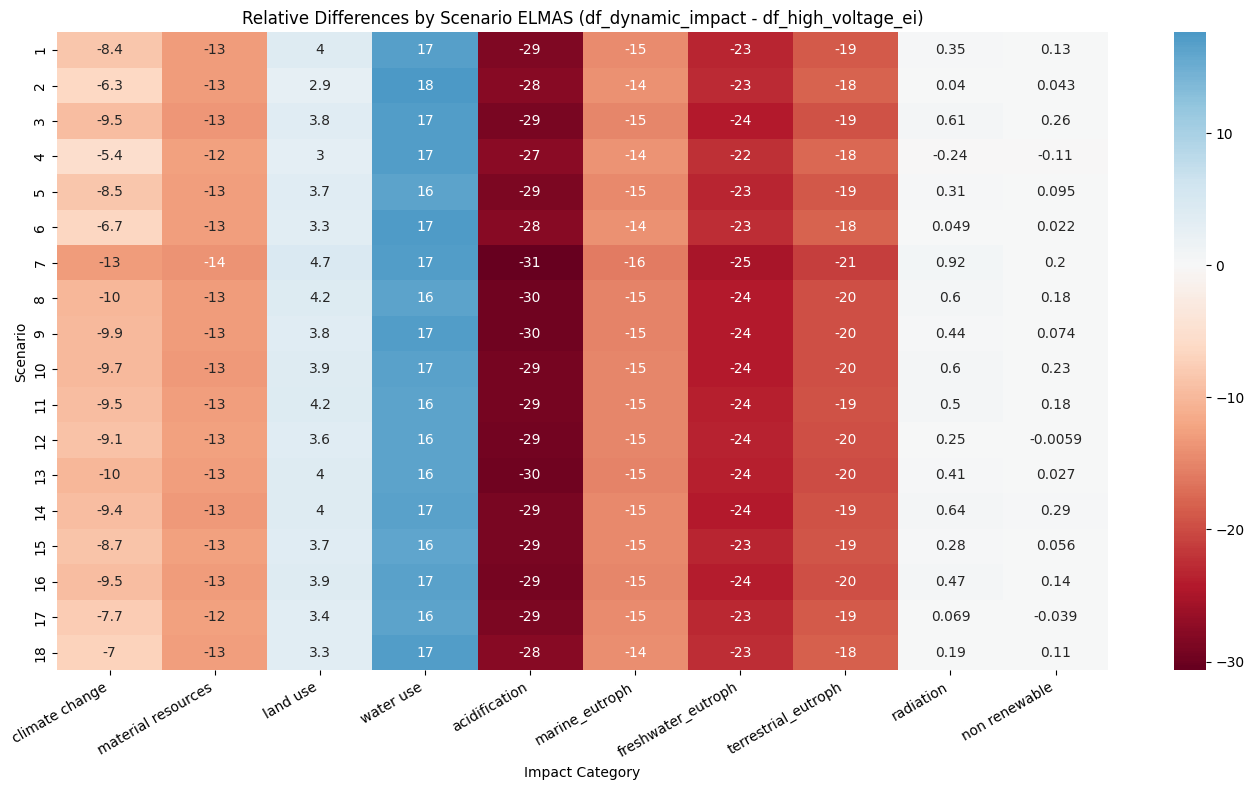

In [83]:
# Heatmap

plt.figure(figsize=(14, 8))
sns.heatmap(relative_diff_elmas_2_3, cmap="RdBu", center=0, annot=True, xticklabels=True, yticklabels=True)
plt.title("Relative Differences by Scenario ELMAS (df_dynamic_impact - df_high_voltage_ei)")
annot=True,       # Add the values to each cell
fmt=".1f",
plt.xlabel("Impact Category")
plt.ylabel("Scenario")
plt.xticks(rotation=30, ha='right')  
plt.tight_layout()
plt.show()

# 2.4 Dynamic (ecoinvent match) x Static (ecoinvent match)

In [84]:
all_exchanges_y = []

for i in range(len(yearly_distributed)):
    row = yearly_distributed.iloc[i]
    
    row_exchanges_per_country = {}
    
    for country in countries:
        exchanges_dict = {}
        
        for col in row.index:
            if col.endswith(f"_{country}"):
                act = activities[country].get(col)
                if act:
                    # Se for lista de atividades, adiciona cada uma com o valor
                    if isinstance(act, list):
                        for a in act:
                            exchanges_dict[a] = row[col]
                    else:
                        exchanges_dict[act] = row[col]
        
        row_exchanges_per_country[country] = exchanges_dict
    
    all_exchanges_y.append(row_exchanges_per_country)

In [85]:
# Extract all country suffixes from dynamic_df columns
countries = set(c.rsplit("_", 1)[1] for c in yearly_distributed.columns if "_" in c)

# Dictionary to store whether total matches per country
totals_check = {}

for country in countries:
    # Sum exchanges from all_exchanges for this country
    total_exchanges_list = [
        sum(all_exchanges_y[i][country].values()) for i in range(len(all_exchanges_y))
    ]
    
    # Sum dynamic_df columns ending with _<country>
    cols_country = [c for c in yearly_distributed.columns if c.endswith(f"_{country}")]
    total_per_row_list = yearly_distributed[cols_country].sum(axis=1).tolist()
    
    # Compare values allowing small numerical differences
    totals_check[country] = np.all(
        np.isclose(total_exchanges_list, total_per_row_list, rtol=1e-5, atol=1e-8)
    )

totals_check

{'BE': True,
 'FR': True,
 'IT': True,
 'ES': True,
 'CH': True,
 'GB': True,
 'DE': True}

In [86]:
results_yearly = []

for i in range(len(yearly_distributed)):
    row_summary = yearly_distributed.iloc[i]

    # Flatten all exchanges from all countries and multiply by losses_map['FR']
    exchanges = {}
    for country_dict in all_exchanges_y[i].values():  # all_exchanges[i] is a dict of countries
        for act, val in country_dict.items():
            exchanges[act] = val * losses_map['FR']  # multiply every numeric value by France losses

    # Scenario activity with dynamic mix
    activity_yearly = agb.newActivity(
        USER_DB,
        name=f"Electricity, Scenario yearly {i + 1}",
        unit="kWh",
        exchanges=exchanges
    )

  
    result_yearly = agb.compute_impacts(activity_yearly, [imp[1] for imp in IMPACTS])
    result_yearly["Scenario"] = i + 1
    results_yearly.append(result_yearly)

# Create two DataFrames
df_yearly_impact = pd.concat(results_yearly, axis=0).set_index("Scenario")
#df_yearly_impact.index = range(1, len(df_yearly_impact) +1)
df_yearly_impact

,climate change - global warming potential (GWP100)[kg CO2-Eq],material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)[kg Sb-Eq],land use - soil quality index[dimensionless],water use - user deprivation potential (deprivation-weighted water consumption)[m3 world eq. deprived],acidification - accumulated exceedance (ae)[mol H+-Eq],eutrophication: marine - fraction of nutrients reaching marine end compartment (N)[kg N-Eq],eutrophication: freshwater - fraction of nutrients reaching freshwater end compartment (P)[kg PO4-Eq],eutrophication: terrestrial - accumulated exceedance (AE)[mol N-Eq],ionising radiation: human health - human exposure efficiency relative to u235[kBq U235-Eq],"energy resources: non-renewable - abiotic depletion potential (ADP): fossil fuels[MJ, net calorific value]"
Scenario,,,,,,,,,,
1,1.45108e+08,457.267,6.90377e+08,3.09269e+08,"522,989","174,003","27,705.8",1.21175e+06,1.04002e+09,2.26455e+10
2,1.4796e+07,46.6253,7.03944e+07,3.15347e+07,"53,326.7","17,742.2","2,825.03","123,556",1.06046e+08,2.30906e+09
3,4.6684e+07,147.111,2.22107e+08,9.94975e+07,"168,255","55,979.8","8,913.46","389,842",3.34592e+08,7.28548e+09
4,3.06643e+07,96.6296,1.4589e+08,6.53548e+07,"110,518","36,770.2","5,854.79","256,067",2.19776e+08,4.78545e+09
5,2.6954e+07,84.9375,1.28238e+08,5.74469e+07,"97,145.4","32,321.1","5,146.37","225,083",1.93184e+08,4.20642e+09
6,1.93879e+07,61.0952,9.22409e+07,4.13214e+07,"69,876.3","23,248.4","3,701.76","161,901",1.38956e+08,3.02566e+09
7,2.49066e+07,78.486,1.18497e+08,5.30835e+07,"89,766.6","29,866.1","4,755.46","207,987",1.7851e+08,3.88691e+09
8,3.33493e+07,105.091,1.58665e+08,7.10773e+07,"120,195","39,989.8","6,367.44","278,488",2.3902e+08,5.20447e+09
9,1.61842e+07,50.9997,7.69988e+07,3.44933e+07,"58,329.8","19,406.8","3,090.07","135,148",1.15995e+08,2.52569e+09


In [87]:
#Impact per kWh
kwh_y = df_yearly_impact['climate change - global warming potential (GWP100)[kg CO2-Eq]']/elmas_yearly_totals['Total Consumption'] 
kwh_y

Scenario
1    0.0731439
2    0.0731439
3    0.0731439
4    0.0731439
5    0.0731439
6    0.0731439
7    0.0731439
8    0.0731439
9    0.0731439
10   0.0731439
11   0.0731439
12   0.0731439
13   0.0731439
14   0.0731439
15   0.0731439
16   0.0731439
17   0.0731439
18   0.0731439
dtype: float64

In [88]:
df_compare_kwh = pd.concat([kwh_d, kwh_y], axis=1)
df_compare_kwh.columns = ["kwh_d", "kwh_y"]
df_compare_kwh

,kwh_d,kwh_y
1,0.0709248,0.0731439
2,0.0725937,0.0731439
3,0.0701148,0.0731439
4,0.073266,0.0731439
5,0.0708454,0.0731439
6,0.0723049,0.0731439
7,0.0674232,0.0731439
8,0.0695342,0.0731439
9,0.0697976,0.0731439
10,0.0699068,0.0731439


In [89]:
df_yearly_impact.index.name = None

# Ensure all indices are int64
df_yearly_impact.index = df_yearly_impact.index.astype('int64')

# Now divide directly using the original column
normalized_df_yearly_impact = df_yearly_impact.div(elmas_yearly_totals['Total Consumption'], axis=0)

absolute_norm_elmas_2_4= normalized_df_dynamic_impact - normalized_df_yearly_impact

# Compare them
absolute_diff_elmas_2_4 = df_dynamic_impact - df_yearly_impact
relative_diff_elmas_2_4 = (absolute_diff_elmas_2_4 / df_yearly_impact) * 100
relative_diff_elmas_2_4= relative_diff_elmas_2_4.rename(columns=dict(zip(relative_diff_elmas_2_4.columns, short_names)))

In [90]:
df_combined_2_4 = pd.concat([
    absolute_norm_elmas_2_4["climate change - global warming potential (GWP100)[kg CO2-Eq]"].rename("Absolute Normalized"),
    absolute_diff_elmas_2_4["climate change - global warming potential (GWP100)[kg CO2-Eq]"].rename("Absolute Raw"),
    relative_diff_elmas_2_4["climate change"].rename("Relative (%)")
], axis=1)
df_combined_2_4.columns.name = "Dynamic vs Market Elec"
df_combined_2_4

Dynamic vs Market Elec,Absolute Normalized,Absolute Raw,Relative (%)
1,-0.00221905,-4.40233e+06,-3.03382
2,-0.000550142,"-111,286",-0.752137
3,-0.0030291,-1.93332e+06,-4.14129
4,0.00012211,"51,192.7",0.166946
5,-0.00229848,"-847,002",-3.1424
6,-0.000838995,"-222,388",-1.14705
7,-0.00572063,-1.94796e+06,-7.82106
8,-0.00360966,-1.64579e+06,-4.93502
9,-0.00334631,"-740,422",-4.57497
10,-0.0032371,-8.2362e+06,-4.42566


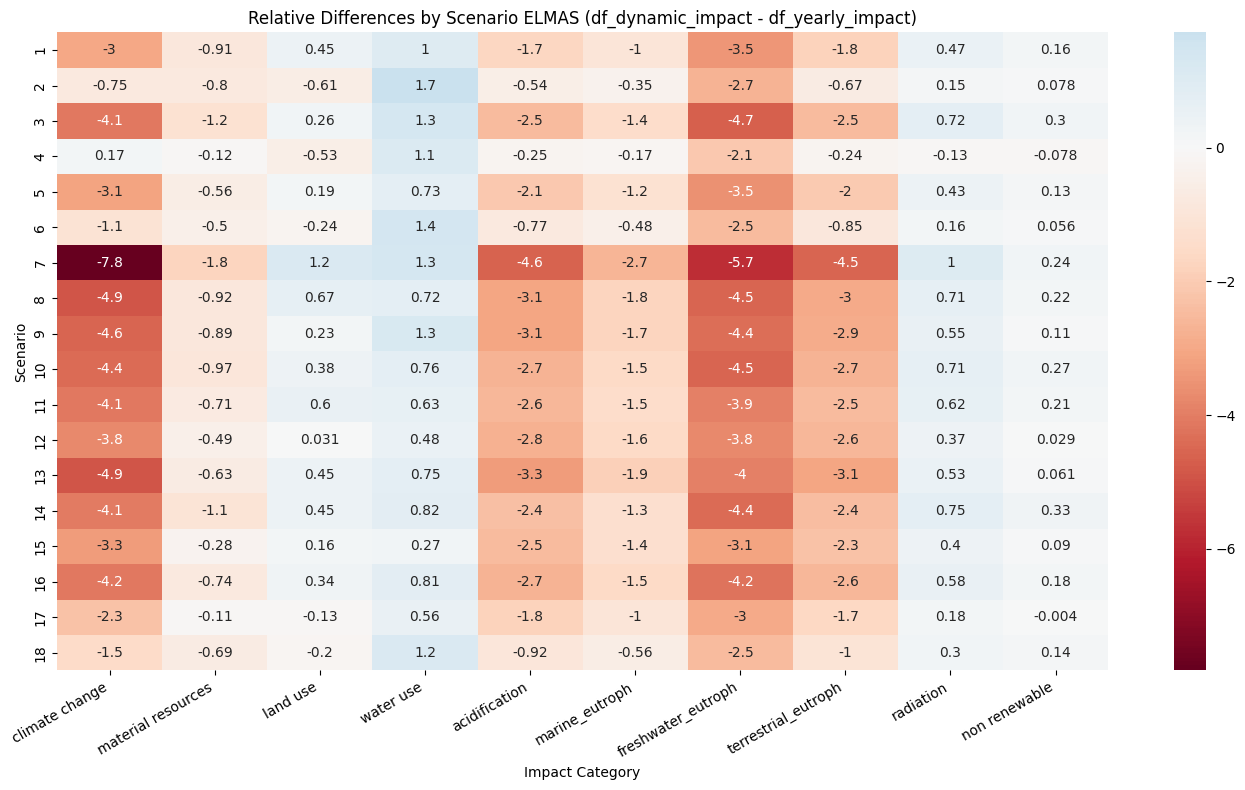

In [91]:
# Heatmap:

plt.figure(figsize=(14, 8))
sns.heatmap(relative_diff_elmas_2_4, cmap="RdBu", center=0, annot=True, xticklabels=True, yticklabels=True)

plt.title("Relative Differences by Scenario ELMAS (df_dynamic_impact - df_yearly_impact)")
plt.xlabel("Impact Category")
plt.ylabel("Scenario")

# Rotaciona e alinha os labels à direita para evitar sobreposição
plt.xticks(rotation=30, ha='right')  # ha='right' => alinha pela extremidade da frase

plt.tight_layout()
plt.show()

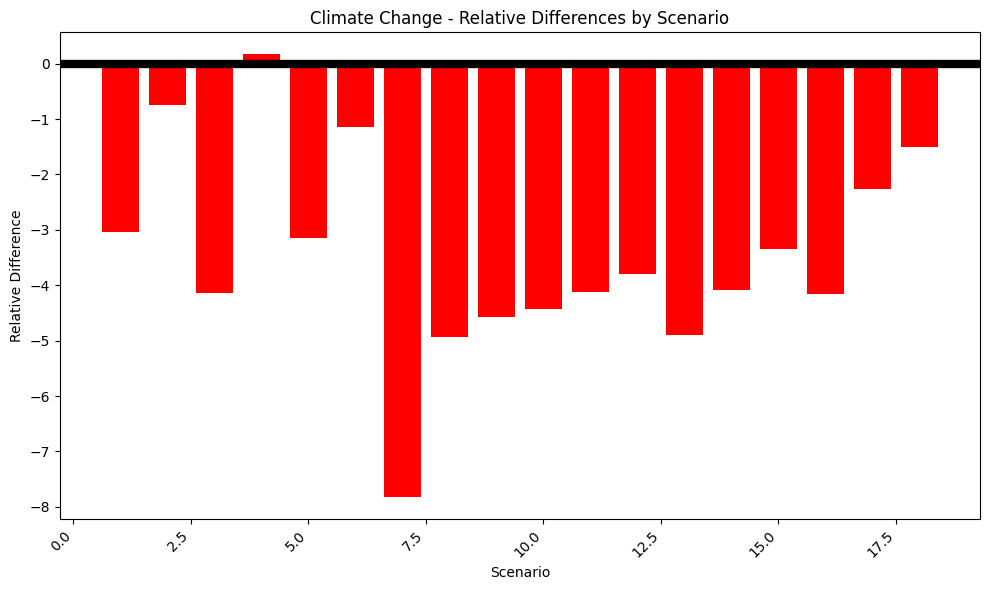

In [92]:
import matplotlib.pyplot as plt

# Extract the first column (climate change)
climate_change_values = relative_diff_elmas_2_4["climate change"]

# Create a bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(climate_change_values.index, climate_change_values, color='red')

# Add thicker horizontal line at y=0
plt.axhline(0, color='black', linewidth=6)  # thicker line

# Add numbers on top/bottom of bars (optional)
for bar in bars:
    yval = bar.get_height()
    # you could add plt.text(...) here if you want numbers

plt.xticks(rotation=45, ha='right')
plt.ylabel("Relative Difference")
plt.xlabel("Scenario")
plt.title("Climate Change - Relative Differences by Scenario")
plt.tight_layout()
plt.show()


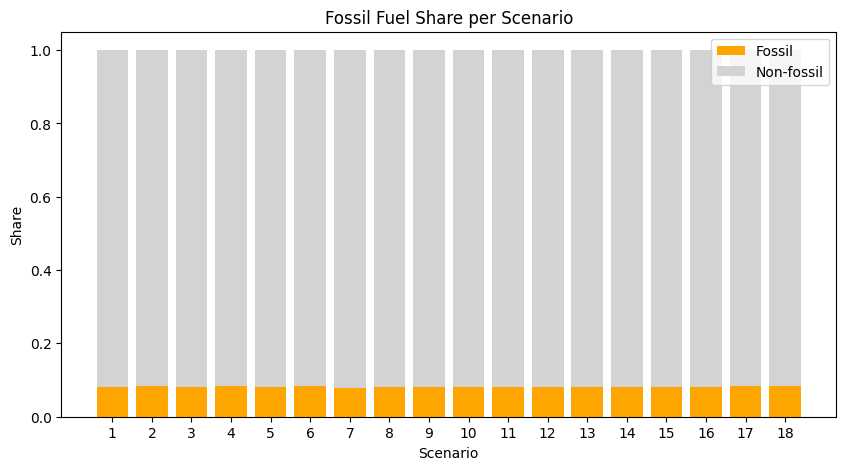

In [106]:
# Make lowercase for easier matching
cols = dynamic_df.columns.str.lower()

# Boolean masks
is_coal = cols.str.contains("coal")
is_oil = cols.str.contains("oil")
is_gas = cols.str.contains("gas") & ~cols.str.contains("biogas") & ~cols.str.contains("blast furnace gas") # exclude biogas and treatment of blast furnace gas, in power plant

# Combine fossil mask
is_fossil = is_coal | is_gas | is_oil

# Fossil subset
df_fossil = dynamic_df.loc[:, is_fossil]

# --- Compute totals and shares ---

# Total per scenario
total_per_scenario = dynamic_df.sum(axis=1)

# Fossil per scenario
fossil_per_scenario = df_fossil.sum(axis=1)

# Share of fossil per total
fossil_share = fossil_per_scenario / total_per_scenario

# Put into DataFrame
df_fossil_share = pd.DataFrame({
    "total": total_per_scenario,
    "fossil": fossil_per_scenario,
    "fossil_share": fossil_share
})

# --- Plot stacked bar chart ---

# Non-fossil share
non_fossil_share = 1 - df_fossil_share['fossil_share']

fig, ax = plt.subplots(figsize=(10,5))

# Fossil part (orange)
ax.bar(df_fossil_share.index, df_fossil_share['fossil_share'], color='orange', label='Fossil')

# Non-fossil part (gray)
ax.bar(df_fossil_share.index, non_fossil_share, bottom=df_fossil_share['fossil_share'], color='lightgray', label='Non-fossil')

# Labels and title
plt.ylabel("Share")
plt.xlabel("Scenario")
plt.title("Fossil Fuel Share per Scenario")
plt.xlabel("Scenario")
ymin = 5
ymax = 10

plt.legend()
plt.show()

In [107]:
df_fossil

,"electricity production, natural gas, combined cycle power plant_FR","electricity production, natural gas, conventional power plant_FR","heat and power co-generation, natural gas, conventional power plant, 100MW electrical_FR","electricity production, hard coal_FR","heat and power co-generation, hard coal_FR","electricity production, oil_FR","heat and power co-generation, oil_FR","electricity production, nuclear, boiling water reactor_DE","electricity production, natural gas, combined cycle power plant_DE","electricity production, natural gas, conventional power plant_DE",...,"heat and power co-generation, hard coal_IT","treatment of coal gas, in power plant_IT","electricity production, oil_IT","heat and power co-generation, oil_IT","electricity production, nuclear, boiling water reactor_ES","electricity production, natural gas, combined cycle power plant_ES","electricity production, natural gas, conventional power plant_ES","electricity production, hard coal_ES","treatment of coal gas, in power plant_ES","electricity production, oil_ES"
1,6.31422e+07,1.21437e+07,3.14695e+07,1.6738e+07,"616,911",6.49391e+06,"296,145",1.55853e+06,"893,358","551,780",...,943.402,"1,105.66",928.736,"6,648.01","558,872",2.87505e+06,"92,063.1",1.69654e+06,"5,365.22","133,413"
2,6.67346e+06,1.28346e+06,3.32599e+06,1.71583e+06,"63,240.2","666,647","30,401.4","159,397","92,714.7","57,265",...,101.466,118.918,99.3391,711.082,"59,139.5","311,857","9,986.09","182,711",577.815,"14,150.7"
3,2.00732e+07,3.86054e+06,1.00043e+07,5.28595e+06,"194,824",2.08513e+06,"95,089.4","500,836","280,367","173,168",...,313.174,367.038,302.661,"2,166.48","179,578","934,464","29,922.8","550,686","1,741.52","42,526"
4,1.40437e+07,2.70093e+06,6.99923e+06,3.51581e+06,"129,582",1.38408e+06,"63,118.8","337,110","197,544","122,013",...,210.954,247.237,203.609,"1,457.46","126,188","665,553","21,312","388,344","1,228.12","30,364"
5,1.17461e+07,2.25904e+06,5.85413e+06,3.04672e+06,"112,293",1.20676e+06,"55,032.3","301,909","171,043","105,644",...,181.149,212.304,176.396,"1,262.67","103,413","531,225","17,010.6","311,940",986.494,"24,496.8"
6,8.68989e+06,1.67127e+06,4.33096e+06,2.23255e+06,"82,284.9","872,240","39,777.2","212,054","122,603","75,725.2",...,132.723,155.55,129.216,924.944,"78,555.4","408,077","13,067.2","239,134",756.25,"18,690.2"
7,1.00559e+07,1.93398e+06,5.01175e+06,2.77646e+06,"102,332",1.10391e+06,"50,342.2","274,327","149,113","92,099.1",...,156.421,183.324,155.73,"1,114.74","87,605.5","434,329","13,907.8","253,688",802.275,"20,469.7"
8,1.41391e+07,2.71927e+06,7.04677e+06,3.74407e+06,"137,995",1.48506e+06,"67,723.9","371,868","206,531","127,563",...,222.857,261.187,216.85,"1,552.24","123,007","629,123","20,145.4","370,473","1,171.6","29,055.3"
9,6.9074e+06,1.32846e+06,3.44258e+06,1.8036e+06,"66,475.3","721,851","32,918.9","182,873","101,728","62,832.2",...,111.939,131.191,109.504,783.844,"60,330.4","309,432","9,908.44","181,051",572.564,"14,184.5"
10,7.95749e+07,1.53041e+07,3.96594e+07,2.10991e+07,"777,650",8.29333e+06,"378,205",2.01329e+06,1.13145e+06,"698,838",...,"1,243.44","1,457.3","1,213.55","8,686.76","699,932",3.60643e+06,"115,483",2.13622e+06,"6,755.7","165,999"


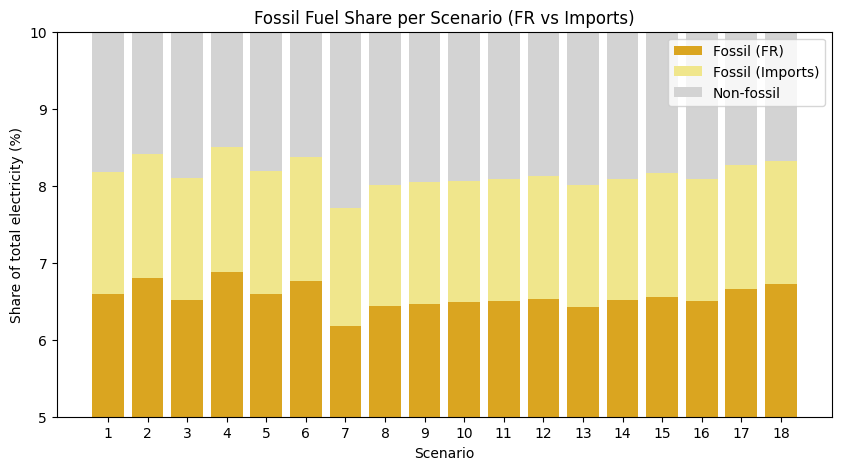

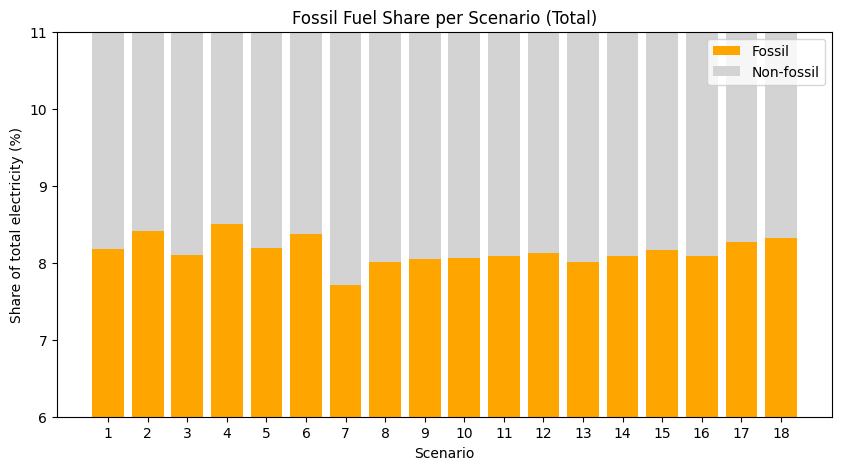

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- masks and shares (keeping your _FR convention) ---
cols = dynamic_df.columns
cols_lower = cols.str.lower()

is_coal = cols_lower.str.contains("coal")
is_oil  = cols_lower.str.contains("oil")
is_gas  = cols_lower.str.contains("gas") & ~cols_lower.str.contains("biogas") & ~cols.str.contains("blast furnace gas")
is_fossil = is_coal | is_gas | is_oil

df_fossil = dynamic_df.loc[:, is_fossil]

# Split FR vs Imports
is_FR = df_fossil.columns.str.endswith("_FR")
df_fossil_fr = df_fossil.loc[:, is_FR]
df_fossil_imports = df_fossil.loc[:, ~is_FR]

# Totals
total_per_scenario = dynamic_df.sum(axis=1)
fossil_fr = df_fossil_fr.sum(axis=1)
fossil_imports = df_fossil_imports.sum(axis=1)
fossil_total = fossil_fr + fossil_imports

# Convert all to %
fossil_fr_share       = 100 * fossil_fr / total_per_scenario
fossil_imports_share  = 100 * fossil_imports / total_per_scenario
fossil_total_share    = 100 * fossil_total / total_per_scenario
non_fossil_share      = 100 - fossil_total_share

df_shares = pd.DataFrame({
    "fossil_fr": fossil_fr_share,
    "fossil_imports": fossil_imports_share,
    "fossil_total": fossil_total_share,
    "non_fossil": non_fossil_share
})

# --- Plot FR vs Imports vs Non-fossil ---
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(df_shares.index, df_shares["fossil_fr"],
       color="goldenrod", label="Fossil (FR)")
ax.bar(df_shares.index, df_shares["fossil_imports"],
       bottom=df_shares["fossil_fr"], color="khaki", label="Fossil (Imports)")
ax.bar(df_shares.index, df_shares["non_fossil"],
       bottom=df_shares["fossil_total"], color="lightgray", label="Non-fossil")

ax.set_ylabel("Share of total electricity (%)")
ax.set_xlabel("Scenario")
ax.set_title("Fossil Fuel Share per Scenario (FR vs Imports)")

plt.ylim(5, 10)
plt.legend()
plt.show()


# --- Plot Total Fossil vs Non-fossil ---
fig, ax = plt.subplots(figsize=(10,5))

ax.bar(df_shares.index, df_shares["fossil_total"], 
       color="orange", label="Fossil")
ax.bar(df_shares.index, df_shares["non_fossil"], 
       bottom=df_shares["fossil_total"], color="lightgray", label="Non-fossil")

ax.set_ylabel("Share of total electricity (%)")
ax.set_xlabel("Scenario")
ax.set_title("Fossil Fuel Share per Scenario (Total)")

plt.ylim(6, 11)
plt.legend()
plt.show()


In [109]:
df_shares

,fossil_fr,fossil_imports,fossil_total,non_fossil
1,6.59821,1.58152,8.17973,91.8203
2,6.80176,1.61011,8.41187,91.5881
3,6.51767,1.57884,8.0965,91.9035
4,6.87838,1.63098,8.50936,91.4906
5,6.58878,1.59605,8.18482,91.8152
6,6.76022,1.60761,8.36783,91.6322
7,6.17729,1.5375,7.7148,92.2852
8,6.43503,1.57825,8.01328,91.9867
9,6.46433,1.58508,8.0494,91.9506
10,6.48845,1.57093,8.05938,91.9406


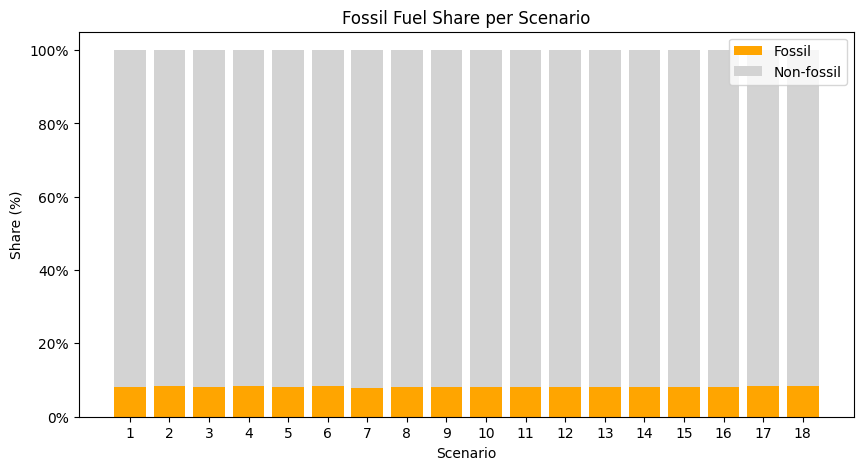

In [110]:
import matplotlib.ticker as mtick

# --- Compute totals and shares ---
cols = dynamic_df.columns.str.lower()
is_coal = cols.str.contains("coal")
is_oil = cols.str.contains("oil")
is_gas = cols.str.contains("gas") & ~cols.str.contains("biogas") & ~cols.str.contains("blast furnace gas")# exclude biogas
is_fossil = is_coal | is_gas | is_oil

df_fossil = dynamic_df.loc[:, is_fossil]

total_per_scenario = dynamic_df.sum(axis=1)
fossil_per_scenario = df_fossil.sum(axis=1)
fossil_share = fossil_per_scenario / total_per_scenario

df_fossil_share = pd.DataFrame({
    "total": total_per_scenario,
    "fossil": fossil_per_scenario,
    "fossil_share": fossil_share
})

# --- Plot stacked bar chart ---
non_fossil_share = 1 - df_fossil_share['fossil_share']

fig, ax = plt.subplots(figsize=(10,5))

# Fossil part (orange)
ax.bar(df_fossil_share.index, df_fossil_share['fossil_share'], color='orange', label='Fossil')

# Non-fossil part (gray)
ax.bar(df_fossil_share.index, non_fossil_share, 
       bottom=df_fossil_share['fossil_share'], color='lightgray', label='Non-fossil')

# Labels and title
ax.set_ylabel("Share (%)")
ax.set_xlabel("Scenario")
ax.set_title("Fossil Fuel Share per Scenario")

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

ymin = 0
ymax = 100

plt.legend()
plt.show()


In [111]:
# Fossil subset
df_fossil_year = yearly_distributed.loc[:, is_fossil]

# --- Compute totals and shares ---

# Total per scenario
total_year = yearly_distributed.sum(axis=1)

# Fossil per scenario
fossil_year= df_fossil_year.sum(axis=1)

# Share of fossil per total
fossil_share_year = fossil_year / total_year 
fossil_share_year


1    0.0848239
2    0.0848239
3    0.0848239
4    0.0848239
5    0.0848239
6    0.0848239
7    0.0848239
8    0.0848239
9    0.0848239
10   0.0848239
11   0.0848239
12   0.0848239
13   0.0848239
14   0.0848239
15   0.0848239
16   0.0848239
17   0.0848239
18   0.0848239
dtype: float64

In [112]:

# Relative climate change differences 
rel_diff_fixed = relative_diff_elmas_2_4['climate change'].copy() 
rel_diff_fixed.index = range(1, len(rel_diff_fixed)+1)
df_compare = pd.DataFrame({
    "fossil_share": fossil_share.values,
    "relative_diff": rel_diff_fixed.values
}, index=fossil_share.index)
# Dados
X = df_compare['fossil_share'].values
y = df_compare['relative_diff'].values

# Ajuste linear (polyfit de grau 1)
a, b = np.polyfit(X, y, 1)

f"Fórmula estimada: Relative Impact = {a:.3f} * Fossil Share + {b:.3f}"

'Fórmula estimada: Relative Impact = 1028.014 * Fossil Share + -87.251'

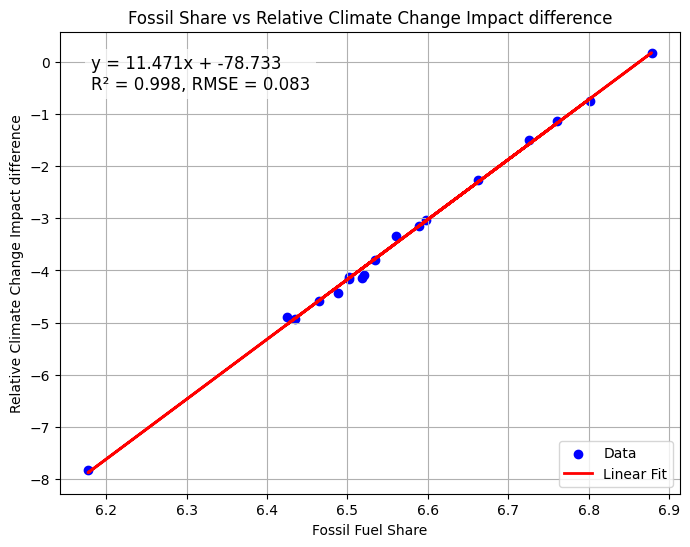

In [113]:
# Fossil share instead of correlation 
fossil_share = df_shares["fossil_fr"].copy() 
fossil_share.index = range(1, len(fossil_share)+1) 
# Relative climate change differences 
rel_diff_fixed = relative_diff_elmas_2_4['climate change'].copy() 
rel_diff_fixed.index = range(1, len(rel_diff_fixed)+1)
df_compare = pd.DataFrame({ "fossil_share": fossil_share.values, "relative_diff": rel_diff_fixed.values }, index=fossil_share.index)

# Prepare data
X = df_compare['fossil_share'].values.reshape(-1, 1)  # independent variable
y = df_compare['relative_diff'].values  # dependent variable

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Get coefficients
a = model.coef_[0]  # slope
b = model.intercept_  # intercept

f"Estimated formula: Relative Impact = {a:.3f} * Fossil Share + {b:.3f}"

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, y_pred, color='red', linewidth=2, label='Linear Fit')
plt.xlabel("Fossil Fuel Share")
plt.ylabel("Relative Climate Change Impact difference")
plt.title("Fossil Share vs Relative Climate Change Impact difference")

# Equation + stats
eq_text = f"y = {a:.3f}x + {b:.3f}\nR² = {r2:.3f}, RMSE = {rmse:.3f}"
plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.legend()
plt.grid(True)
plt.show()

In [114]:
corr = df_compare['fossil_share'].corr(df_compare['relative_diff'])
f"Pearson correlation: {corr:.3f}"

'Pearson correlation: 0.999'

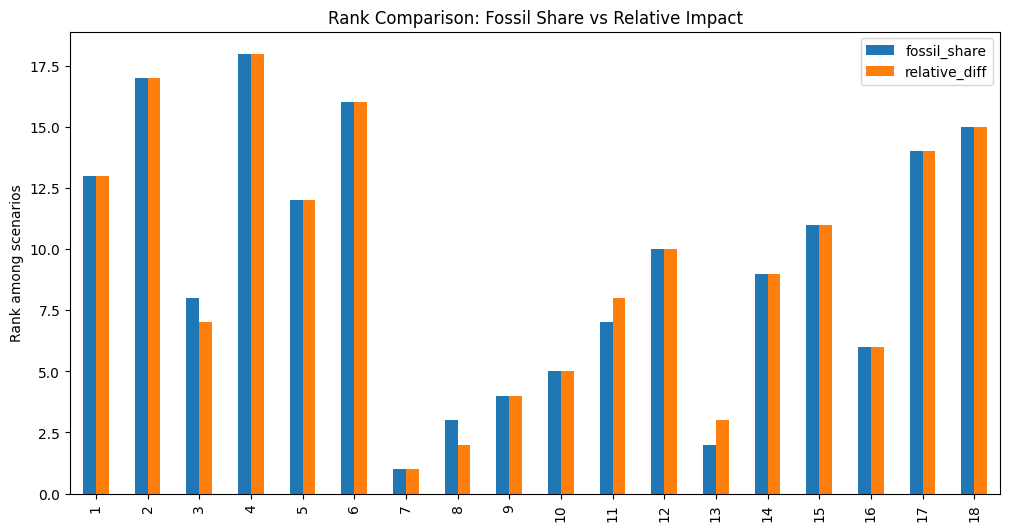

In [102]:
df_compare_ranked = df_compare.rank()
df_compare_ranked.plot(kind='bar', figsize=(12,6))
plt.ylabel("Rank among scenarios")
plt.title("Rank Comparison: Fossil Share vs Relative Impact")
plt.show()


In [103]:
# Lowercase for easier matching
cols = df_FR_total_consumption_ei_match_d.columns.str.lower()

# Boolean masks
is_coal = cols.str.contains("coal")
is_oil = cols.str.contains("oil")
is_gas = cols.str.contains("gas") & ~cols.str.contains("biogas")  # exclude biogas

# Combine fossil mask
is_fossil = is_coal | is_gas | is_oil

# Fossil subset
df_fossil = df_FR_total_consumption_ei_match_d.loc[:, is_fossil]

# Check rows where all fossil values are zero
fossil_free_hours = (df_fossil == 0).all(axis=1)

# Count how many hours
num_hours_fossil_free = fossil_free_hours.sum()

f"Number of hours with zero coal, oil, and gas: {num_hours_fossil_free}"


'Number of hours with zero coal, oil, and gas: 0'

# 2.5 Static (ecoinvent match) x Static (market for electricity, high voltage FR)

In [104]:
# Compare them, 2 static databases will result in the same difference regardless of the scenario
absolute_diff_elmas_2_5 =  df_yearly_impact - df_high_voltage_ei
relative_diff_elmas_2_5 = (absolute_diff_elmas_2_5 / df_yearly_impact) * 100
relative_diff_elmas_2_5= relative_diff_elmas_2_5.rename(columns=dict(zip(relative_diff_elmas_2_5.columns, short_names)))

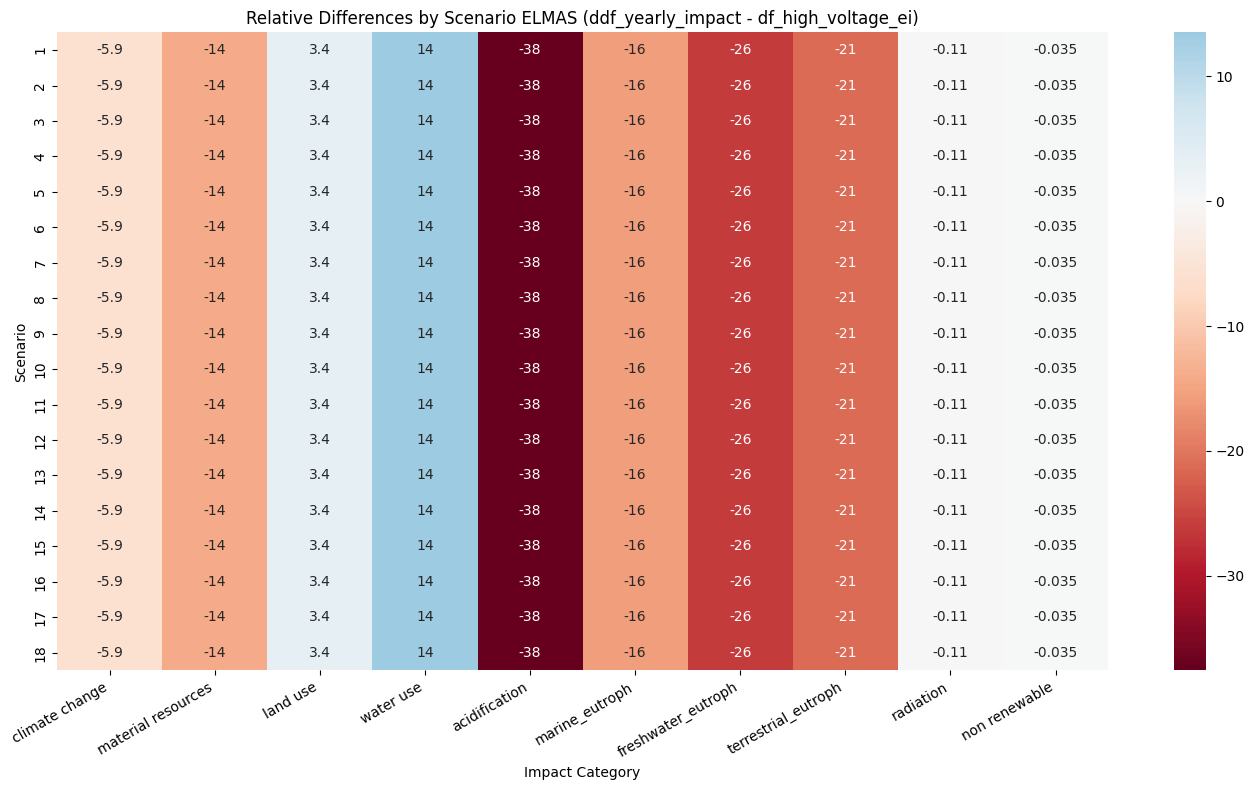

In [105]:
plt.figure(figsize=(14, 8))
sns.heatmap(relative_diff_elmas_2_5, cmap="RdBu", center=0, annot=True, xticklabels=True, yticklabels=True)

plt.title("Relative Differences by Scenario ELMAS (ddf_yearly_impact - df_high_voltage_ei)")
plt.xlabel("Impact Category")
plt.ylabel("Scenario")

# Rotaciona e alinha os labels à direita para evitar sobreposição
plt.xticks(rotation=30, ha='right')  # ha='right' => alinha pela extremidade da frase

plt.tight_layout()
plt.show()